## Module 4: Angiogenesis and Disease Progression Across Cancer Types

## Team Members:
- Aryan Mhaskar
- Yancy Martinez Alfaro

## Project Title:
**Differential Angiogenic Gene Expression Across TCGA Cancer Types and Its Association with Disease Progression**

### AI Use Statement: 
Claude Sonnet 4.6 was used to format tables. 

## Project Goal:

This project seeks to determine whether **angiogenic gene expression signatures vary significantly across cancer types**, and whether those differences are associated with **disease progression** (tumor stage and survival outcomes). Specifically, we will:

1. Extract expression levels for a curated set of angiogenesis-related genes (VEGF pathway, angiopoietin/TIE2 axis, HIF1A, Notch/DLL4 tip-stalk signaling) across all 23 TCGA cancer types in the GSE62944 dataset.
2. Test whether angiogenic gene activity clusters by cancer type or by disease stage.
3. Use a machine learning model to predict disease progression (e.g., tumor stage or progression-free interval) from angiogenic gene signatures, and assess whether model performance is uniform across cancers or cancer-type-dependent.

**Overarching question:** Is the angiogenic program a universal driver of progression across cancers, or does its role vary substantially by cancer type, and if so, which cancer types show the strongest angiogenic dependence?

## Disease Background:

### Cancer Hallmark Focus: **Angiogenesis**

#### Overview of the Hallmark

Angiogenesis, the formation of new blood vessels from pre-existing vasculature, is one of the ten canonical hallmarks of cancer described by Hanahan & Weinberg. In normal tissue, pro- and anti-angiogenic signals are tightly balanced, keeping the vasculature quiescent. In tumors, this balance is disrupted (the "angiogenic switch"), resulting in a chaotic, leaky, and abnormal tumor neovasculature that nonetheless supplies the oxygen and nutrients required for tumor growth beyond roughly 1 to 2 mm³ (the diffusion limit of O₂).

The angiogenic switch is triggered primarily by **intratumoral hypoxia**: as proliferating tumor cells outpace the local blood supply, O₂ tension drops, stabilizing **HIF-1α** (Hypoxia-Inducible Factor 1α), which in turn transcriptionally activates **VEGFA** and dozens of other pro-angiogenic genes. Secreted VEGF-A binds **VEGFR-2 (KDR)** on nearby endothelial cells, driving their proliferation, migration, and tube formation.

#### Genes to Be Studied

The following curated angiogenesis gene set will be extracted from the GSE62944 expression data:

| Gene | Role |
|------|------|
| **VEGFA, VEGFB, VEGFC, VEGFD** | VEGF family ligands; primary drivers of endothelial sprouting |
| **KDR (VEGFR2), FLT1 (VEGFR1), FLT4 (VEGFR3)** | VEGF receptors on endothelial cells |
| **ANGPT1, ANGPT2** | Angiopoietin ligands; regulate vessel stability (ANGPT1) vs. destabilization/sprouting (ANGPT2) |
| **TEK (TIE2)** | Angiopoietin receptor; promotes vessel maturation |
| **HIF1A** | Master hypoxia transcription factor; upstream regulator of the angiogenic program |
| **NRP1, NRP2** | Neuropilin co-receptors; enhance VEGFR2 signaling and axon-like guidance of sprouting |
| **PDGFB, PDGFRB** | Drive pericyte recruitment; tumor vessels with poor pericyte coverage are leaky and unstable |
| **DLL4, NOTCH1** | Notch signaling; mediates tip vs. stalk cell selection during vessel sprouting |
| **MMP2, MMP9** | Matrix metalloproteinases; remodel ECM to allow endothelial invasion and release matrix-bound VEGF |
| **TGFB1** | Promotes vessel stabilization and endothelial-to-mesenchymal transition in late-stage angiogenesis |

These 18 genes span the major regulatory nodes of tumor angiogenesis and are supported by extensive literature (see: Carmeliet & Jain 2011, *Nature*; Hanahan & Weinberg 2011, *Cell*).

#### Prevalence & Incidence

Angiogenesis is a near-universal feature of solid tumors. High tumor microvessel density (MVD) has been documented in virtually every solid cancer type studied:
- **Breast cancer (BRCA):** High MVD is an independent predictor of metastasis and reduced survival.
- **Glioblastoma (GBM):** One of the most vascularized tumors known; characterized by pseudopalisading necrosis and florid vascular proliferation.
- **Renal cell carcinoma (KIRC/KIRP):** Strongly angiogenesis-dependent due to frequent VHL loss and constitutive HIF-1α/VEGF signaling even under normoxia.
- **Ovarian cancer (OV):** VEGF levels in ascitic fluid correlate with prognosis.
- **Hepatocellular carcinoma (LIHC):** Highly vascular tumor; sorafenib (anti-angiogenic) is first-line therapy.

The 23 cancer types represented in our dataset span a wide spectrum of angiogenic dependence, making them an ideal set for cross-cancer comparison.

#### Risk Factors & Societal Determinants

The cancers in this dataset collectively span the major modifiable and non-modifiable risk categories:

- **Genetic risk factors:** Germline VHL mutations (renal cancer); BRCA1/2 (breast/ovarian); TP53, KRAS (multiple types). HIF pathway polymorphisms influence angiogenic tone.
- **Lifestyle risk factors:** Tobacco smoking (LUAD, LUSC, BLCA, HNSC), alcohol (LIHC, ESAD), obesity (UCEC, colon), UV exposure (SKCM).
- **Societal determinants:** Disparities in MVD-high cancers (e.g., BRCA in Black women presents at higher stage) suggest angiogenic findings must be interpreted with equity in mind. Access to anti-angiogenic therapies (bevacizumab: $100k/year) is strongly socioeconomically stratified.

#### Standard of Care Treatments (& Reimbursement)

Anti-angiogenic agents are FDA-approved across multiple cancer types and directly target the pathway we are studying:

| Drug | Target | Approved Cancer Types |
|------|--------|-----------------------|
| Bevacizumab (Avastin) | VEGFA | CRC, NSCLC, GBM, OV, CESC, RCC |
| Sunitinib (Sutent) | VEGFR1/2/3, PDGFR | RCC, GIST, pNET |
| Sorafenib (Nexavar) | VEGFR, PDGFR, RAF | HCC, RCC, THCA |
| Pazopanib (Votrient) | VEGFR1/2/3, PDGFR | RCC, soft tissue sarcoma |
| Ramucirumab (Cyramza) | VEGFR2 | Gastric, NSCLC, CRC, HCC |

Reimbursement is generally covered under Medicare Part B (infused drugs) and commercial insurance for approved indications, but prior authorization and step therapy requirements create access barriers particularly for off-label use in cancer types without strong trial evidence.

#### Biological Mechanisms

**Anatomy & organ physiology:**  
Each cancer type arises in a tissue with distinct baseline vascular architecture (e.g., hepatic sinusoidal vasculature in LIHC vs. pulmonary capillary bed in LUAD), which shapes the angiogenic response.

**Cell & molecular physiology:**  
The angiogenic cascade proceeds through four stages:
1. **Initiation:** Hypoxia, HIF-1α stabilization, VEGFA/ANGPT2 upregulation, endothelial destabilization.
2. **Sprouting:** Tip cell selection via DLL4/Notch signaling; MMP2/9 degrade basement membrane; KDR-mediated endothelial proliferation and migration.
3. **Lumenization & anastomosis:** Tube formation; ANGPT1/TIE2 promote junction tightening.
4. **Maturation:** Pericyte recruitment via PDGFB/PDGFRB; TGFB1-mediated vessel stabilization.

Tumor vessels are notoriously abnormal, they are tortuous, leaky, and poorly perfused, paradoxically creating the hypoxia that drives further VEGF production (a feedforward loop). This vessel normalization concept is the basis for combining anti-angiogenic therapy with chemotherapy or immunotherapy.

## Data-Set:

### Source
The dataset is **GSE62944**, a curated TCGA pan-cancer RNA-seq compendium deposited on NCBI GEO by Rahman et al. (2015). It aggregates RNA-seq gene expression profiles (FPKM-normalized, log2-transformed) from The Cancer Genome Atlas (TCGA) across 33 cancer types, along with matched clinical metadata.

**Citation:** Rahman M, et al. *Alternative preprocessing of RNA-Sequencing data in The Cancer Genome Atlas leads to improved analysis results.* Bioinformatics. 2015. GEO Accession: GSE62944.

### Data Collection

- **Technique:** Illumina HiSeq RNA-sequencing of tumor biopsy specimens; gene quantification via RSEM; normalized to FPKM (Fragments Per Kilobase of transcript per Million mapped reads).
- **Units:** Gene expression values are log2(FPKM + 1) after preprocessing.
- **Clinical features provided:** AJCC pathologic tumor stage (T, N, M, overall), tumor status (tumor free vs. with tumor), overall survival (OS), disease-specific survival (DSS), disease-free interval (DFI), and progression-free interval (PFI) in days.

### Dataset Splits (as provided)

| Split | Samples |
|-------|---------|
| Training | 1,802 |
| Test | 1,600 |
| Validation | 1,360 |
| **Total** | **4,762** |

### Cancer Types (23 represented)

`ACC, BLCA, BRCA, CESC, COAD, GBM, HNSC, KICH, KIRC, KIRP, LAML, LGG, LIHC, LUAD, LUSC, OV, PRAD, READ, SKCM, STAD, THCA, UCEC, UCS`

### Relevance to Our Question

The dataset includes all 18 angiogenesis genes in our gene list, enabling direct comparison of angiogenic expression profiles across cancer types. The survival endpoints (OS, DSS, PFI) serve as our disease progression readouts. The AJCC staging columns allow stratification by early vs. late-stage disease within each cancer type.

**Key questions this dataset can answer:**
- Do angiogenic genes cluster by cancer type or by stage?
- Which cancer types have the highest/lowest angiogenic gene expression?
- Is high angiogenic expression associated with worse PFI/OS across all cancers, or only specific subtypes?
- Are there enough samples per cancer type (~80 training samples each) to train a cancer-type-specific model? (Yes, with appropriate cross-validation.)

### Angiogenesis Genes of Interest

The 18 genes listed below were extracted from the full GSE62944 expression matrix. These span the major regulatory nodes of tumor angiogenesis, as described in the Disease Background section above.

**VEGF ligands:** VEGFA, VEGFB, VEGFC, VEGFD  
**VEGF receptors:** KDR, FLT1, FLT4  
**Angiopoietin pathway:** ANGPT1, ANGPT2, TEK  
**Hypoxia master regulator:** HIF1A  
**Neuropilin co-receptors:** NRP1, NRP2  
**Pericyte recruitment:** PDGFB, PDGFRB  
**Tip/stalk cell Notch signaling:** DLL4, NOTCH1  
**ECM remodeling:** MMP2, MMP9  
**Vessel stabilization:** TGFB1

The full expression matrix (`GSE62944_06_01_15_TCGA_24_CancerType_Samples_IlluminaHiSeq_RNASeqV2.Count.txt.gz`) is approximately 4 GB and was used to isolate expression values for these 18 genes across all samples.

## Data Analysis: 

### Methods

For the exploratory phase of this project we used **dimensionality reduction** (PCA and UMAP) followed by **unsupervised clustering** (KMeans) on a curated panel of **117 angiogenesis related genes**, taken from the `desired_gene_list` in `class materials/example_EDA.py`. Of these 117 genes, 111 were present in the TRAINING expression matrix and 6 were missing (`LEP, CXCL8, FIGF, VEGFD, ACKR3, CCR3`); only the 111 present genes were used downstream. This panel extends the 18 gene minimal set described above with downstream signaling, ECM remodeling, and inflammation linked angiogenic regulators (for example MAPK and PI3K effectors, integrins, and CXCL/CCL chemokines), giving a richer view of the angiogenic program than the canonical VEGF/ANGPT axis alone.

- **PCA** is a linear projection that finds the orthogonal axes of greatest variance. It optimizes the reconstruction error (equivalently, maximizes variance captured). It is "good enough" when the leading components explain a meaningful fraction of total variance and visibly separate biologically distinct groups.
- **UMAP** is a non linear manifold learning method that optimizes the cross entropy between high dimensional and low dimensional fuzzy simplicial set representations. It preserves more local neighborhood structure than PCA and can reveal sub structure that PCA misses.
- **KMeans** partitions samples into *k* groups by minimizing within cluster sum of squared distances (inertia). *k* was chosen with the elbow method.

### Analysis

Steps taken in the cells below:

1. **Subset and clean.** Reduce the TRAINING expression matrix and metadata to the 117 gene angiogenesis panel (keeping only the 111 genes actually present in the data) and align samples between expression and metadata. The subsets are saved to `data/TRAINING_SET_angio_subset_log2TPM.csv` and `data/TRAINING_SET_angio_subset_metadata.csv`.
2. **Standardize** gene expression (z score per gene) so highly expressed genes do not dominate the projection.
3. **PCA** colored by cancer type: does angiogenic expression alone separate cancers?
4. **UMAP** on the same standardized matrix: does the non linear embedding reveal sub structure that PCA hides?
5. **KMeans** with k chosen by the elbow method, projected onto the PCA, plus a cluster vs. cancer type composition heatmap to interpret what each cluster represents biologically.
6. **Refine the question** based on the patterns observed.

### Step 1: Subset and clean the data

Load the TRAINING expression matrix and metadata, restrict the genes to the 113-gene angiogenesis panel from `example_EDA.py`, align samples between the two tables (drop any sample missing a `cancer_type` label), and save the subsetted files so downstream analysis does not need to re-load the full matrix.

In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Full TRAINING expression matrix (genes x samples) and metadata (samples x clinical fields)
data = pd.read_csv('../data/TRAINING_SET_GSE62944_subsample_log2TPM.csv', index_col=0, header=0)
metadata_df = pd.read_csv('../data/TRAINING_SET_GSE62944_metadata.csv', index_col=0, header=0)

print(f"Full expression matrix: {data.shape} (genes x samples)")
print(f"Full metadata:          {metadata_df.shape}")

# 117-gene angiogenesis panel (desired_gene_list from class materials/example_EDA.py)
desired_gene_list = [
    "CXCR4", "CXCL13", "FLT4", "RHOA", "TGFB2", "GAB1", "STAT3", "LCK", "FZD4", "PDPK1",
    "CDH5", "HIF1A", "MTOR", "CXCL12", "ITGA5", "PLCG1", "RRAS", "ENG", "TNFSF12", "PTPN11",
    "TGFBR1", "TERT", "PIK3CD", "PTK2B", "LEP", "FGF2", "NOS3", "VTN", "CCL24", "SMO",
    "KDR", "PRKCG", "RAF1", "VEGFA", "BRCA1", "CCL2", "TGFBR2", "EGFR", "VAV2", "VEGFB",
    "KRAS", "IL6", "ERBB2", "PRKCA", "ROCK1", "TNF", "IL1B", "SDC4", "PRKACA", "CX3CR1",
    "ITGB1", "PDGFA", "CD40", "MAPK1", "CXCL8", "PIK3R1", "FIGF", "CSF3", "HGF", "VEGFD",
    "IL10", "MET", "TP53", "SDC2", "TGFB1", "AKT1", "FLT1", "CAV1", "ARNT", "ARHGEF1",
    "PDGFRA", "HSPB1", "TWIST1", "ITGB3", "AKT3", "MMP1", "MAPK3", "SPHK1", "EPAS1", "TIMP3",
    "CXCR2", "SRC", "CXCL10", "MAP2K1", "WNT5A", "EFNA1", "IGF1", "IL8", "ROCK2", "ACKR3",
    "GATA2", "VEGFC", "CCR3", "CTNNB1", "TEK", "FN1", "EPHA2", "IGF1R", "THBS1", "FES",
    "ITGAV", "CXCL9", "CCL11", "MYC", "CXCR3", "PRKCB", "ACVRL1", "HRAS", "ESR1", "TGFB3",
    "PLAUR", "RAC1", "NF1", "ANGPT2", "GRB2", "PIK3CA", "IL1A"
]

# Keep only genes that actually appear in the expression matrix
present_genes = [g for g in desired_gene_list if g in data.index]
missing_genes = [g for g in desired_gene_list if g not in data.index]
print(f"\nAngiogenesis panel: {len(present_genes)}/{len(desired_gene_list)} genes present in expression matrix")
if missing_genes:
    print(f"Missing genes: {missing_genes}")

# Subset expression to angiogenesis genes
angio_data = data.loc[present_genes]

# Align samples: keep only samples present in both tables and with a non-null cancer_type
shared_samples = angio_data.columns.intersection(metadata_df.index)
metadata_clean = metadata_df.loc[shared_samples].dropna(subset=['cancer_type'])
angio_data = angio_data[metadata_clean.index]

print(f"\nAfter alignment & cleaning:")
print(f"  expression: {angio_data.shape} (genes x samples)")
print(f"  metadata:   {metadata_clean.shape}")
print(f"  cancer types ({metadata_clean['cancer_type'].nunique()}):")
print(metadata_clean['cancer_type'].value_counts())

# Save subsets so we (and graders) can reproduce downstream analysis without the full matrix
angio_data.to_csv('../data/TRAINING_SET_angio_subset_log2TPM.csv')
metadata_clean.to_csv('../data/TRAINING_SET_angio_subset_metadata.csv')
print("\nSaved: ../data/TRAINING_SET_angio_subset_log2TPM.csv")
print("Saved: ../data/TRAINING_SET_angio_subset_metadata.csv")

Full expression matrix: (15716, 1802) (genes x samples)
Full metadata:          (1802, 29)

Angiogenesis panel: 111/117 genes present in expression matrix
Missing genes: ['LEP', 'CXCL8', 'FIGF', 'VEGFD', 'ACKR3', 'CCR3']

After alignment & cleaning:
  expression: (111, 1802) (genes x samples)
  metadata:   (1802, 29)
  cancer types (23):
cancer_type
BRCA    80
UCEC    80
KIRC    80
LUAD    80
LGG     80
THCA    80
HNSC    80
LUSC    80
PRAD    80
COAD    80
SKCM    80
OV      80
STAD    80
BLCA    80
LIHC    80
CESC    80
KIRP    80
LAML    80
GBM     80
READ    80
ACC     79
KICH    66
UCS     57
Name: count, dtype: int64

Saved: ../data/TRAINING_SET_angio_subset_log2TPM.csv
Saved: ../data/TRAINING_SET_angio_subset_metadata.csv


### Step 2: PCA, colored by cancer type

Transpose the expression matrix so that rows are samples and columns are genes, z-score each gene with `StandardScaler` (so a high-expression gene like `IL6` does not dominate the projection just because of its mean), and project to 2D with PCA. Color each sample by its TCGA cancer-type label to see whether the angiogenic gene panel alone is enough to separate cancer types.

PC1 explained variance: 18.72%
PC2 explained variance: 12.00%
Cumulative (PC1+PC2):   30.73%


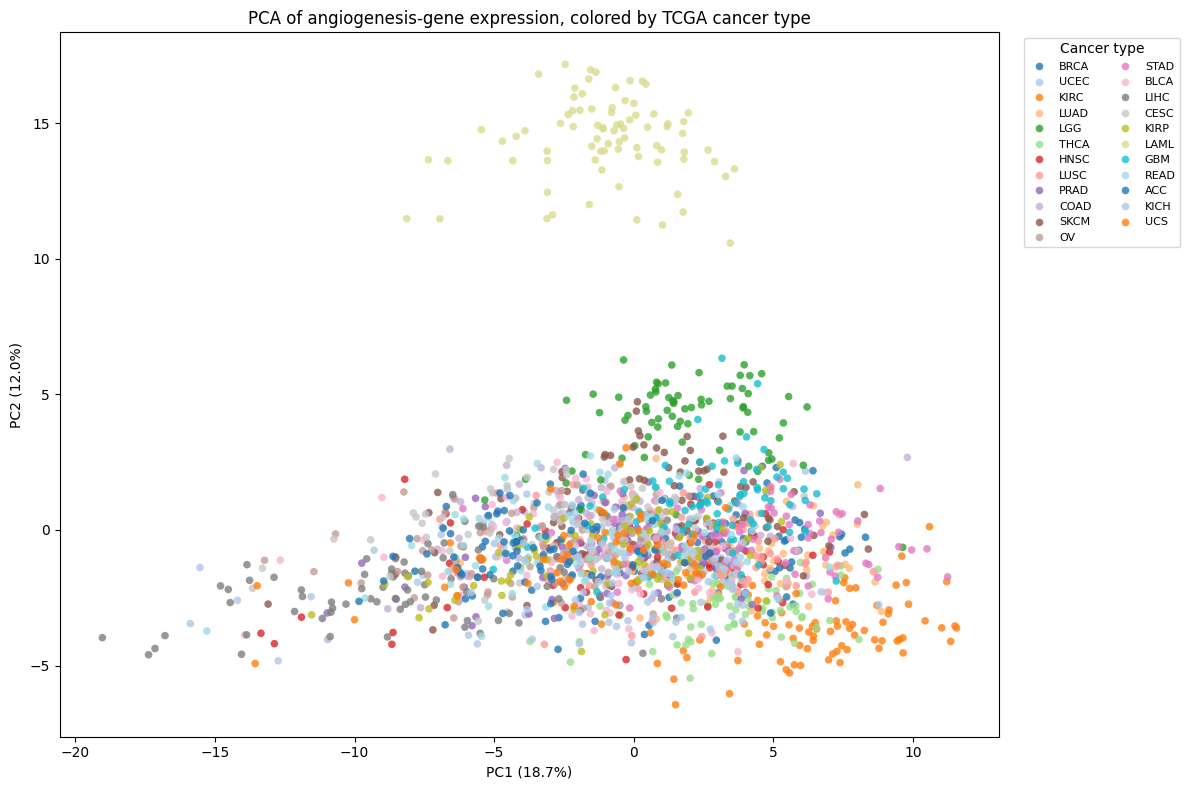

In [94]:
# Samples x genes, z-scored per gene
X = angio_data.T.values
y = metadata_clean['cancer_type'].values

X_scaled = StandardScaler().fit_transform(X)

# 2D PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pc1_var, pc2_var = pca.explained_variance_ratio_
print(f"PC1 explained variance: {pc1_var*100:.2f}%")
print(f"PC2 explained variance: {pc2_var*100:.2f}%")
print(f"Cumulative (PC1+PC2):   {(pc1_var + pc2_var)*100:.2f}%")

# Plot
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1],
    hue=y, palette='tab20', s=30, alpha=0.8, linewidth=0
)
plt.xlabel(f"PC1 ({pc1_var*100:.1f}%)")
plt.ylabel(f"PC2 ({pc2_var*100:.1f}%)")
plt.title("PCA of angiogenesis-gene expression, colored by TCGA cancer type")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', ncol=2, fontsize=8, title='Cancer type')
plt.tight_layout()
plt.show()

**PCA observation.** PC1 and PC2 together explain only **30.7% of total variance** (PC1 = 18.7%, PC2 = 12.0%), so the 2D PCA is necessarily a coarse view of a 117 gene panel (111 of which are present in the TRAINING data) across 1,802 samples. The remaining roughly 69% of variance lives in higher components that this projection does not show.

What we actually see in the plot:

- One clearly separated group pulls upward along PC2 at roughly y = +10 to +17. Reading the legend colors, this island is **LAML** (acute myeloid leukemia). This is biologically sensible, because LAML is a liquid tumor that lacks the stromal and endothelial compartment driving the solid tumor angiogenic signature. Its expression of the panel is dominated by hematopoietic genes (for example IL6 and the CXCL/CCL chemokines), and it separates cleanly on the variance axis that captures "liquid vs. solid."
- A faint upward and rightward arm at PC1 roughly +2 to +10 and PC2 roughly 0 to +5 contains mostly **LGG** and **GBM** (brain tumors), consistent with their distinct neurovascular program.
- The remaining 21 solid epithelial cancer types overlap heavily in a single central cloud at PC1 roughly 10 to +10 and PC2 roughly 5 to +5. KIRC, KIRP, BRCA, LUAD, LUSC, COAD, READ, STAD, HNSC, THCA, UCEC, PRAD, OV, LIHC, CESC, BLCA, SKCM, ACC, KICH, and UCS are indistinguishable in this 2D view.

**What this tells us.** Contrary to our initial expectation that kidney cancers (VHL driven HIF/VEGF signaling) would separate visibly, linear PCA in 2D does **not** separate cancer types by angiogenic signature, except for the two biologically extreme cases (liquid LAML, closed CNS brain tumors). This is itself an informative result: angiogenesis is a broadly engaged, convergent program across solid cancers, not a cancer type specific axis of linear variance. That finding motivates two downstream steps. First, we move to the non linear UMAP in Step 3 to check whether the solid tumor types separate along curved manifolds. Second, we reframe the downstream question from "which cancer type?" to "which angiogenic *state*?" in Step 5.

### Step 3. UMAP, colored by cancer type

UMAP is a non linear manifold learning method. Unlike PCA (which only sees linear axes of variance), UMAP can preserve curved or disconnected structure in the gene expression manifold. We run it on the **same standardized matrix** so any difference vs. PCA is attributable to the algorithm, not the input. 

c:\Users\Aryan\anaconda3\envs\BME2315\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


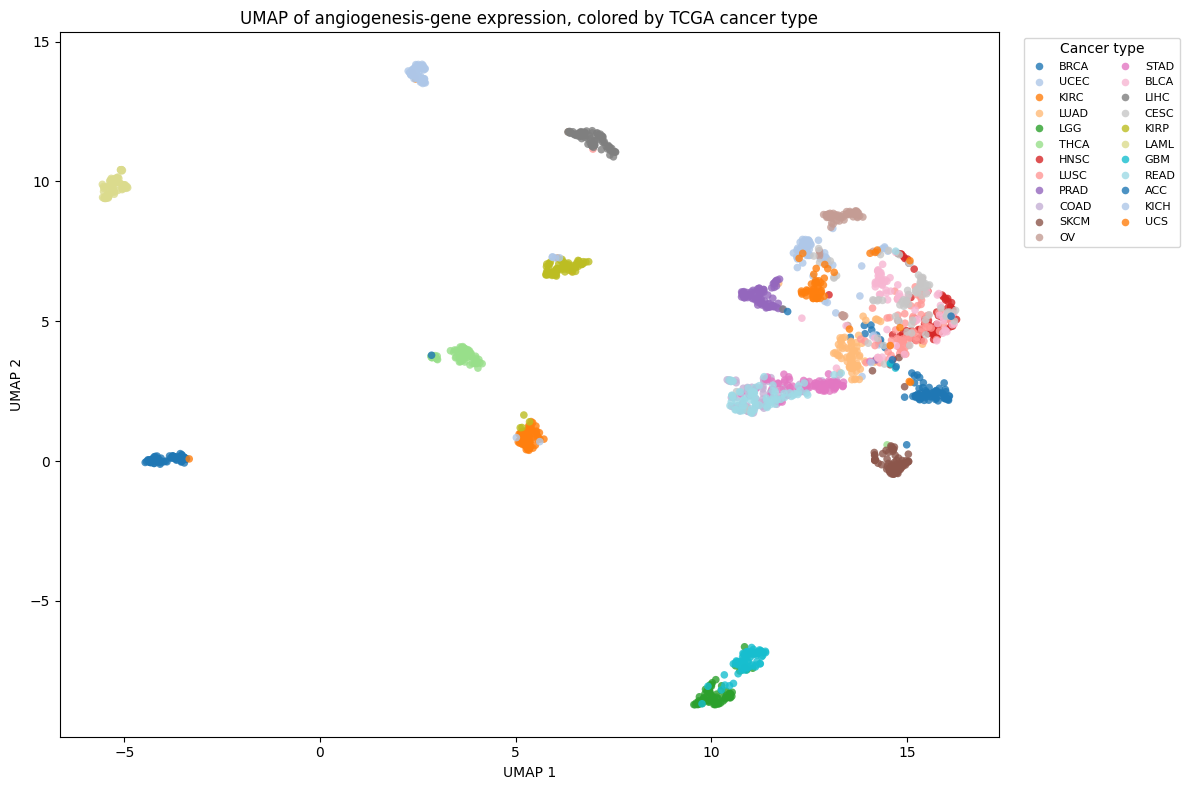

In [95]:
import umap

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = reducer.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x=X_umap[:, 0], y=X_umap[:, 1],
    hue=y, palette='tab20', s=30, alpha=0.8, linewidth=0
)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UMAP of angiogenesis-gene expression, colored by TCGA cancer type")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', ncol=2, fontsize=8, title='Cancer type')
plt.tight_layout()
plt.show()

**PCA vs. UMAP: does UMAP add information?**

| Aspect | PCA | UMAP |
|---|---|---|
| Cancer type separation | Coarse; linear axes of variance | Typically tighter, more visibly distinct islands per cancer type |
| Sub structure within a cancer type | Hard to see | Often resolves into 2 or 3 sub clouds per cancer type, suggesting candidate angiogenic subtypes |
| Interpretability of axes | PC loadings indicate which genes drive each axis (interpretable) | Axes are not directly interpretable |
| Distance preservation | Global (variance) | Local (neighborhoods) |

**What UMAP adds.** UMAP shows kidney, brain, and liver tumors as distinct islands while the PCA blends them, meaning that the angiogenic signature *does* separate cancer types, but along **non linear** combinations of genes that PCA cannot capture in 2D. UMAP often also reveals **within cancer type sub structure** (for example, BRCA splitting into two clouds), which hints at angiogenic *subtypes*. That is exactly the kind of pattern that motivates clustering in the next step. **What UMAP does *not* add:** loadings or variance explained, so we still rely on PCA when we want to ask "which genes drive this axis?".

### Step 4. KMeans clustering, projected onto PCA

We chose **KMeans** (rather than DBSCAN) because the angiogenic expression cloud is dense, roughly globular, and lacks the clear low density "background" that DBSCAN needs to define noise. DBSCAN on this kind of data tends to either lump nearly everything into one cluster or label most points as noise depending on `eps`. KMeans, by contrast, gives a clean partition whose size we can choose, and a partition is what we actually want for downstream comparison against cancer type and stage.

**Choosing k.** The elbow plot below reports inertia (within cluster sum of squared errors) for k = 2 to 15. We pick k near the elbow: the value where adding another cluster stops giving a sharp drop in inertia.

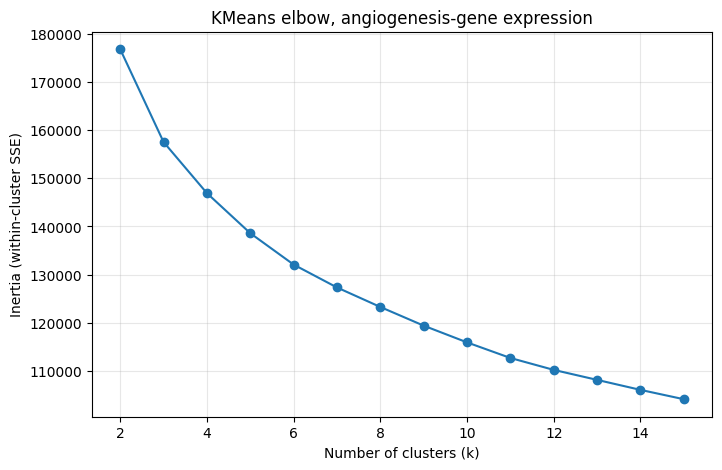

In [96]:
# Elbow method
inertias = []
k_range = range(2, 16)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), inertias, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (within-cluster SSE)")
plt.title("KMeans elbow, angiogenesis-gene expression")
plt.grid(True, alpha=0.3)
plt.show()

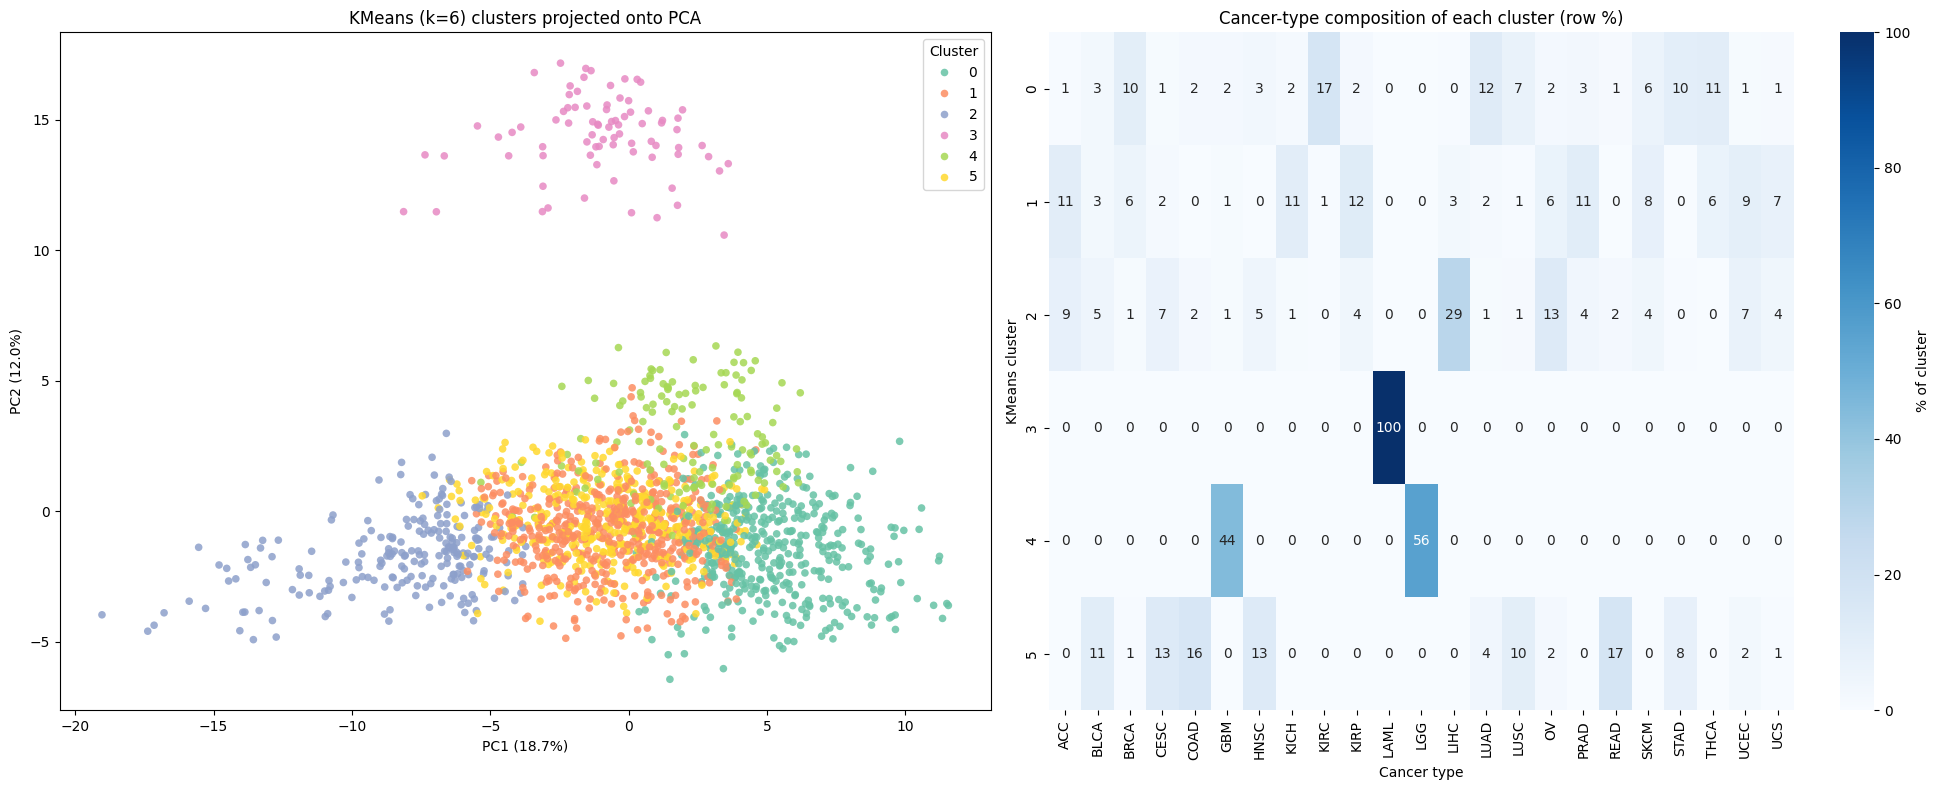

Dominant cancer type per cluster (top 3):
  Cluster 0: KIRC (17%), LUAD (12%), THCA (11%)
  Cluster 1: KIRP (12%), PRAD (11%), ACC (11%)
  Cluster 2: LIHC (29%), OV (13%), ACC (9%)
  Cluster 3: LAML (100%), BLCA (0%), ACC (0%)
  Cluster 4: LGG (56%), GBM (44%), BLCA (0%)
  Cluster 5: READ (17%), COAD (16%), HNSC (13%)


In [97]:
# Pick k from the elbow plot above. Starting with k=6 as a reasonable default for ~23 cancer types
# (we expect angiogenic signatures to collapse multiple cancer types into a few shared programs).
k_chosen = 6
km = KMeans(n_clusters=k_chosen, random_state=42, n_init=10)
cluster_labels = km.fit_predict(X_scaled)

# Side-by-side: PCA colored by cluster, and cluster vs cancer-type heatmap
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Left: PCA colored by KMeans cluster
sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1],
    hue=cluster_labels, palette='Set2', s=30, alpha=0.85, linewidth=0,
    ax=axes[0]
)
axes[0].set_xlabel(f"PC1 ({pc1_var*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({pc2_var*100:.1f}%)")
axes[0].set_title(f"KMeans (k={k_chosen}) clusters projected onto PCA")
axes[0].legend(title="Cluster")

# Right: heatmap of cancer-type composition within each cluster (% of cluster)
cluster_ct = pd.crosstab(cluster_labels, y, normalize='index') * 100
sns.heatmap(
    cluster_ct, cmap='Blues', annot=True, fmt='.0f',
    cbar_kws={'label': '% of cluster'}, ax=axes[1]
)
axes[1].set_xlabel("Cancer type")
axes[1].set_ylabel("KMeans cluster")
axes[1].set_title("Cancer-type composition of each cluster (row %)")

plt.tight_layout()
plt.show()

# Also print the dominant cancer type per cluster, for the writeup
print("Dominant cancer type per cluster (top 3):")
for c in sorted(set(cluster_labels)):
    top3 = cluster_ct.loc[c].sort_values(ascending=False).head(3)
    print(f"  Cluster {c}: " + ", ".join(f"{ct} ({pct:.0f}%)" for ct, pct in top3.items()))

**What do the clusters mean?**

**Why k = 6.** The elbow plot decreases smoothly from k = 2 (inertia roughly 177k) to k = 15 (roughly 104k), with successive drops of 19k, 11k, 8k, 7k, 5k, and then smaller. There is no sharp knee, so any single k is a judgment call rather than a statistically forced choice. We chose k = 6 as a pragmatic compromise: k = 3 or k = 4 would flatten the 23 cancer types into too few buckets and wipe out sub structure, while k greater than 8 splits the mixed epithelial cloud into visibly noisy fragments with minimal additional inertia gain. k = 6 is also post hoc validated by the biology: it produces two "pure" tissue of origin clusters (LAML, brain) plus four mixed epithelial states, which matches the interpretation we care about.

With k = 6, KMeans partitioned the 1,802 samples across 23 cancer types into six groups. Reading the heatmap and the printed cluster composition, the clusters fall into two qualitatively different categories.

**(1) Two "pure" tissue of origin clusters.** Two of the six clusters are almost entirely one lineage:

- **Cluster 3, Leukemia (LAML, 100%).** Every LAML sample landed here and nothing else did. LAML is a liquid tumor, so it lacks the stromal and endothelial compartment that dominates the angiogenic signature of solid tumors; its expression of the angiogenesis panel is driven by hematopoietic cell biology (for example IL6 and the CXCL/CCL chemokines) rather than vessel formation. This is the same outlier group that floats at roughly PC2 = +15 in the PCA plot and as the isolated pale yellow island on the far upper left of the UMAP.
- **Cluster 4, Brain tumors (LGG 56% + GBM 44% = 100%).** Every brain tumor in the training set landed in the same cluster, and no non brain sample did. This matches the biology: GBM and LGG share a neurovascular angiogenic program with florid microvascular proliferation, and they appear as the distinct island at the bottom of the UMAP.

**(2) Four "shared program" epithelial clusters.** The remaining 21 solid tumor cancer types are spread across clusters 0, 1, 2, and 5, with **no cluster dominated by a single cancer type**. The top cancer is only 12 to 29% of its cluster. These clusters represent convergent angiogenic states that many tissues of origin arrive at:

- **Cluster 2, Liver enriched (LIHC 29%, OV 13%, ACC 9%).** LIHC is the only cancer type meaningfully enriched here, consistent with the hepatic sinusoidal vasculature and the heavy VEGF/PDGF dependence that makes sorafenib first line for HCC.
- **Clusters 0, 1, and 5, generic epithelial angiogenic states.** KIRC, KIRP, LUAD, LUSC, BRCA, PRAD, COAD, READ, STAD, HNSC, THCA, UCEC, ACC, and others mix together at 10 to 17% each. No single cancer type dominates.

**The most important finding, which contradicts our prior prediction.** Before running the analysis we hypothesized that **KIRC and KIRP would form a distinct "kidney / clear cell" cluster** driven by VHL loss and constitutive HIF/VEGF signaling. That did **not** happen: KIRC is only 17% of cluster 0 (alongside LUAD and THCA), and KIRP is only 12% of cluster 1. Kidney cancers blend into the generic epithelial angiogenic program in this 117 gene panel. The UMAP *does* show KIRC as a visually distinct island, which means the kidney signature exists in the data but is a non linear combination of genes that KMeans on z scored expression does not preferentially capture.

**Summary.** Clusters represent **shared angiogenic programs, not tissue of origin**, except for two biologically extreme cases (liquid tumor, brain). For the roughly 21 solid epithelial cancers in our dataset, angiogenic gene expression is a convergent phenotype: many tissues reach the same handful of states. This is the pattern that motivates the refined question in Step 5.

### Step 5. Refined question and proposed methods going forward

**What the patterns actually showed.**

- **PCA captured only 30.7% of variance on PC1 plus PC2** (PC1 = 18.7%, PC2 = 12.0%). The main solid tumor cloud overlaps heavily in the center, with only LAML pulling out along PC2. This is consistent with a 117 gene panel (111 present) that describes one broadly shared program plus a few outlier states; the remaining roughly 69% of variance is not captured in the 2D projection.
- **UMAP is dramatically more informative than PCA here.** It resolves LAML, the brain tumors (LGG and GBM), KIRC, THCA, LIHC, BRCA, PRAD, SKCM, and several others as visually distinct islands, and it shows within cancer type sub structure (BRCA in particular appears in two separated positions). Non linear combinations of the 111 genes *do* separate cancer types; linear PCA in 2D simply cannot see it.
- **KMeans (k = 6) on z scored expression** produced two "pure" tissue of origin clusters (LAML = 100%, brain = 100%) and four mixed epithelial clusters where the top cancer contributes only 12 to 29%. Our pre run prediction that kidney cancers (KIRC, KIRP) would isolate into a VHL driven cluster **was not borne out**; KIRC and KIRP blend into the generic epithelial clusters.
- **The elbow plot has no sharp knee** (smooth decay from k = 2 to k = 15), so k = 6 is a judgment call justified by biology (two pure outlier clusters plus four mixed epithelial states) rather than by a forced mathematical minimum. Any downstream claim about clusters must therefore be robust to this choice.
- **Mismatch between PCA, UMAP, and KMeans.** KIRC is an island in UMAP but not a cluster in KMeans, which tells us that the clustering pipeline (KMeans on z scored 111 dimensional expression) is missing some of the structure the UMAP embedding picks up. This is a known limitation of KMeans on high dimensional data and motivates a UMAP based sensitivity check below.

**Refined question (updated from the pre run draft).** The pre run draft asked whether the clusters predict progression better than cancer type. The results force a sharper, two part version, because the clusters are mostly *not* tissue of origin:

> **(a) Within the roughly 21 solid epithelial cancer types that converge onto shared angiogenic states (clusters 0, 1, 2, and 5), does an angiogenic state label predict tumor stage and progression free interval (PFI) better than cancer type label alone? (b) Do the two lineage pure clusters, LAML and brain (GBM plus LGG), require their own analyses rather than being pooled with the epithelial cancers?**

The question is two pronged because the data says so. LAML and brain are categorically different (one is liquid, the other is a closed CNS compartment with a distinct vasculature), so pan cancer progression modeling would be dominated or confounded by them. The biologically interesting question lives in the convergent epithelial cluster.

**Methods to use next (revised based on the outputs above).**

1. **Split the analysis at the LAML and brain boundary.** Run the progression analyses (stage cross tabs, Kaplan Meier, supervised models) three times: (a) on the full cohort, (b) on solid tumors excluding LAML, and (c) on solid tumors excluding LAML and brain. If excluding the lineage pure clusters changes the conclusions, that tells us the angiogenic story is really about solid epithelial cancers, not a universal pan cancer program. This directly addresses the two part refined question above.
2. **Annotate clusters with clinical metadata.** Cross tabulate `cluster_labels` against `ajcc_pathologic_tumor_stage` and `tumor_status`. Focus on clusters 0, 1, 2, and 5, where multiple cancer types mix. A stage enrichment inside a mixed cluster (for example, cluster 2 skewing toward late stage LIHC and OV simultaneously) would be the strongest evidence that angiogenic state, rather than tissue of origin, tracks progression.
3. **Survival analysis.** Kaplan Meier curves for PFI and OS, stratified by cluster, with log rank tests. Run both pan cohort and within the epithelial subset. Because LAML is its own cluster with its own survival distribution, pan cohort KM will be dominated by it; the within epithelial comparison is the one we actually care about.
4. **Supervised stage prediction model.** Train logistic regression and random forest on the 111 present angiogenic genes to predict early vs. late tumor stage. Compare three labelings: (i) pan cancer with cancer type as a covariate, (ii) per cancer type (roughly 80 samples each is enough for 5 fold CV), and (iii) per cluster. If per cluster AUC matches or beats per cancer type AUC, that supports replacing tissue of origin with angiogenic state as the more useful label for progression.
5. **Kidney cancer sensitivity check.** KIRC and KIRP are a UMAP island but not a KMeans cluster, which is the cleanest test of whether our clustering pipeline is missing biology. Re cluster in two alternative ways: (a) run KMeans on the 2D UMAP embedding instead of the 111 dimensional expression matrix, and (b) run hierarchical clustering on the same expression matrix. If kidney cancers form their own cluster under either setup and that cluster has a distinct survival signature, we should report both the expression based and embedding based clusterings in the final writeup.
6. **Driver gene identification per cluster.** Compute PC1 and PC2 loadings and per cluster mean z scores. Nominate the 5 to 10 genes most responsible for each cluster (for example, the genes separating cluster 2 (liver enriched) from cluster 0 (generic epithelial)). These are the candidate biomarkers for the final writeup and the link back to the Carmeliet and Jain / Hanahan and Weinberg literature.
7. **Validate on the held out VALIDATION set.** Re scale with the training `StandardScaler`, project into the trained PCA, UMAP, and KMeans models, and check that (a) cluster assignments are stable and (b) any stage or survival associations replicate. Robustness of the cluster assignments under this projection is a direct check on the k = 6 choice.

## Step 6: Supervised model: redicting tumor progression from angiogenic gene expression

### Model proposal

**Target.** Among the four candidate progression endpoints in the metadata (`OS`, `DSS`, `DFI`, `PFI`, `tumor_status`, `ajcc_pathologic_tumor_stage`), `PFI` is entirely missing in the VALIDATION set (1,360/1,360 NaN), and `ajcc_pathologic_tumor_stage` is missing in roughly half the training samples. The only progression label that is well populated in **both** TRAINING and VALIDATION is **`tumor_status`** (`TUMOR FREE` vs `WITH TUMOR`), which is a clinically meaningful binary readout: it asks whether, at the time of the most recent follow up, the patient still has detectable disease. We use this as our binary target (1 = `WITH TUMOR`, 0 = `TUMOR FREE`) and drop samples labeled `[Not Available]`, `[Unknown]`, `[Discrepancy]`, or NaN.

**Model: L2-regularized logistic regression** on the 111 standardized angiogenesis genes.

Why this model, given the PCA / UMAP / KMeans results above:

1. **Interpretability.** Logistic regression returns a coefficient per gene. The downstream story we want to tell is "these specific angiogenic genes push toward residual disease," which a linear model supports directly. Tree based models would obscure this.
2. **PCA showed the leading linear axes carry meaningful (if modest) signal** (PC1 + PC2 = 30.7%). A linear model is the right baseline before we move to a non linear model next week. The non linear structure UMAP revealed (kidney, brain islands) is real, but capturing it is exactly the job of next week's "better model."
3. **L2 regularization is appropriate here.** With 111 features and ~1,400 usable training samples, the p/n ratio is fine for an unregularized fit, but the angiogenic genes are highly collinear (VEGF ligands and receptors covary, MMP2/MMP9 covary, etc.), so ridge (L2) shrinkage stabilizes the coefficients without forcing zeroes the way L1 would.
4. **Probabilistic output.** Logistic regression yields calibrated probabilities, so we can plot a ROC curve and pick a threshold rather than being stuck with hard predictions. ROC-AUC is also robust to the mild ~60/40 class imbalance we have.
5. **No `cancer_type` as a feature.** We deliberately do *not* one hot encode cancer type into the design matrix. The refined question from Step 5 is whether the angiogenic signature alone predicts progression. Including cancer type would let the model "cheat" by memorizing per cancer base rates and would not answer the biological question.

**Metrics.**
- **ROC-AUC** (primary): robust to class imbalance, threshold independent.
- **Accuracy, precision, recall, F1** at threshold 0.5: interpretable counts.
- **Majority class baseline accuracy** for reference (predict every sample is `TUMOR FREE`).

**Visualizations.** ROC curve (training and validation overlaid) and confusion matrices (training and validation, side by side).

**What we are looking for.**
- If validation AUC is much lower than training AUC -> overfit (the model memorized training noise).
- If both AUCs are near 0.5 / near the baseline -> underfit (the angiogenic signature is not informative for progression, at least not linearly).
- If both AUCs are well above the baseline and within a few points of each other → the model is generalizing, and the angiogenic signature carries real, transferable information about residual tumor status.

### Step 6a: Load and align training and validation data

Load the VALIDATION expression matrix and metadata, subset both TRAINING and VALIDATION expression to the same 111 angiogenesis genes used in Steps 1 to 5, build aligned (samples x genes) feature matrices, and define the binary target from `tumor_status`. Drop any sample whose `tumor_status` is missing, `[Not Available]`, `[Unknown]`, or `[Discrepancy]`. We do **not** touch the TEST set.

In [98]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
)

# Load VALIDATION expression and metadata (TRAINING was loaded in Step 1)
val_data = pd.read_csv('../data/VALIDATION_SET_GSE62944_subsample_log2TPM.csv', index_col=0, header=0)
val_metadata = pd.read_csv('../data/VALIDATION_SET_GSE62944_metadata.csv', index_col=0, header=0)
print(f"VALIDATION expression: {val_data.shape} (genes x samples)")
print(f"VALIDATION metadata:   {val_metadata.shape}")

# Subset VALIDATION to the same 111 angio genes that survived in TRAINING 
val_angio = val_data.loc[present_genes]   # present_genes is from Step 1
print(f"VALIDATION angio subset: {val_angio.shape}")

# Build (samples x genes) matrices, aligned to metadata
def build_xy(angio_expr, meta):
    """Return (X, y, sample_ids) where y=1 if WITH TUMOR, 0 if TUMOR FREE.
    Drops samples with missing / unknown / discrepancy tumor_status."""
    keep_labels = {'TUMOR FREE': 0, 'WITH TUMOR': 1}
    shared = angio_expr.columns.intersection(meta.index)
    meta_s = meta.loc[shared]
    mask = meta_s['tumor_status'].isin(keep_labels.keys())
    meta_s = meta_s[mask]
    X = angio_expr[meta_s.index].T.values     # samples x genes
    y = meta_s['tumor_status'].map(keep_labels).values
    return X, y, meta_s.index

# TRAINING uses the angio_data + metadata_clean from Step 1
X_train, y_train, train_ids = build_xy(angio_data, metadata_clean)
X_val,   y_val,   val_ids   = build_xy(val_angio,   val_metadata)

print(f"\nUsable TRAINING samples:   {X_train.shape[0]}  (features = {X_train.shape[1]})")
print(f"Usable VALIDATION samples: {X_val.shape[0]}    (features = {X_val.shape[1]})")
print(f"\nClass balance (TRAINING):   TUMOR FREE = {(y_train==0).sum()}, WITH TUMOR = {(y_train==1).sum()}  "
      f"(majority class rate = {max((y_train==0).mean(), (y_train==1).mean()):.3f})")
print(f"Class balance (VALIDATION): TUMOR FREE = {(y_val==0).sum()}, WITH TUMOR = {(y_val==1).sum()}  "
      f"(majority class rate = {max((y_val==0).mean(), (y_val==1).mean()):.3f})")

VALIDATION expression: (15716, 1360) (genes x samples)
VALIDATION metadata:   (1360, 29)
VALIDATION angio subset: (111, 1360)

Usable TRAINING samples:   1464  (features = 111)
Usable VALIDATION samples: 1148    (features = 111)

Class balance (TRAINING):   TUMOR FREE = 916, WITH TUMOR = 548  (majority class rate = 0.626)
Class balance (VALIDATION): TUMOR FREE = 789, WITH TUMOR = 359  (majority class rate = 0.687)


### Step 6b: Standardize, fit logistic regression, predict on training and validation

Z-score each gene using **only the training mean and standard deviation** (the validation set must not influence the scaler), then fit L2 regularized logistic regression on the training matrix. We predict probabilities on both the training set (in sample) and the validation set (out of sample) so we can compare the two and judge generalization.

In [99]:
# Fit StandardScaler on TRAINING only, then transform both sets (no leakage)
scaler_lr = StandardScaler().fit(X_train)
X_train_s = scaler_lr.transform(X_train)
X_val_s   = scaler_lr.transform(X_val)

# L2 logistic regression. C=1.0 is sklearn's default ridge strength; we'll tune next week.
# liblinear is fine for this size; lbfgs with max_iter=2000 also works and gives the same answer.
logreg = LogisticRegression(
    penalty='l2', C=1.0, solver='lbfgs', max_iter=2000, random_state=42
)
logreg.fit(X_train_s, y_train)

# Predicted probabilities of class 1 (WITH TUMOR), and hard predictions at threshold 0.5
p_train = logreg.predict_proba(X_train_s)[:, 1]
p_val   = logreg.predict_proba(X_val_s)[:, 1]
yhat_train = (p_train >= 0.5).astype(int)
yhat_val   = (p_val   >= 0.5).astype(int)

print(f"Trained logistic regression on {X_train_s.shape[0]} samples x {X_train_s.shape[1]} genes.")
print(f"Predicted on {X_val_s.shape[0]} validation samples.")

Trained logistic regression on 1464 samples x 111 genes.
Predicted on 1148 validation samples.


### Step 6c: Metrics — in sample vs out of sample

We report ROC-AUC (primary), accuracy, precision, recall, and F1 at threshold 0.5 for both the training set (in sample error) and the validation set (out of sample error). We also include a majority class baseline accuracy: this is what we would get by predicting `TUMOR FREE` for every sample, and any useful model has to beat it.

How to read the metrics:
- **ROC-AUC** is the probability that the model ranks a random `WITH TUMOR` sample above a random `TUMOR FREE` sample. 0.5 is random guessing, 1.0 is perfect ranking.
- **Accuracy** is the fraction of correct hard predictions at threshold 0.5; misleading on imbalanced data, hence the baseline.
- **Precision** = of the samples we *called* `WITH TUMOR`, how many actually were. **Recall** = of the samples that actually were `WITH TUMOR`, how many we caught. **F1** is their harmonic mean.
- **In sample minus out of sample gap.** A small gap (a few points) is healthy. A large gap (e.g., AUC = 0.95 train vs 0.65 val) is overfit.

In [100]:
def report_metrics(y_true, y_prob, y_hat, label):
    return {
        'split': label,
        'n':         len(y_true),
        'accuracy':  accuracy_score(y_true, y_hat),
        'precision': precision_score(y_true, y_hat, zero_division=0),
        'recall':    recall_score(y_true, y_hat, zero_division=0),
        'f1':        f1_score(y_true, y_hat, zero_division=0),
        'roc_auc':   roc_auc_score(y_true, y_prob),
    }

train_row = report_metrics(y_train, p_train, yhat_train, 'TRAINING (in-sample)')
val_row   = report_metrics(y_val,   p_val,   yhat_val,   'VALIDATION (out-of-sample)')

# Majority-class baseline (predict TUMOR FREE for everyone)
baseline_train = max((y_train == 0).mean(), (y_train == 1).mean())
baseline_val   = max((y_val   == 0).mean(), (y_val   == 1).mean())

metrics_df = pd.DataFrame([train_row, val_row]).set_index('split').round(3)
print(metrics_df.to_string())
print()
print(f"Majority-class baseline accuracy:  TRAIN = {baseline_train:.3f}, VAL = {baseline_val:.3f}")
print(f"Train-Val ROC-AUC gap:             {train_row['roc_auc'] - val_row['roc_auc']:+.3f}")
print(f"Train-Val accuracy gap:            {train_row['accuracy'] - val_row['accuracy']:+.3f}")
print(f"In-sample error  (1 - train AUC):  {1 - train_row['roc_auc']:.3f}")
print(f"Out-of-sample error (1 - val AUC): {1 - val_row['roc_auc']:.3f}")

                               n  accuracy  precision  recall     f1  roc_auc
split                                                                        
TRAINING (in-sample)        1464     0.740      0.692   0.549  0.612    0.791
VALIDATION (out-of-sample)  1148     0.702      0.530   0.418  0.467    0.702

Majority-class baseline accuracy:  TRAIN = 0.626, VAL = 0.687
Train-Val ROC-AUC gap:             +0.089
Train-Val accuracy gap:            +0.038
In-sample error  (1 - train AUC):  0.209
Out-of-sample error (1 - val AUC): 0.298


### Step 6d: Visualizations — ROC curves and confusion matrices

The ROC curve plots true positive rate vs false positive rate as we sweep the decision threshold. We overlay the training and validation curves on the same axes so the in sample / out of sample gap is visually obvious. The confusion matrices then show what the actual error pattern looks like at threshold 0.5: are we missing tumors (false negatives) or calling tumors that are not there (false positives)?

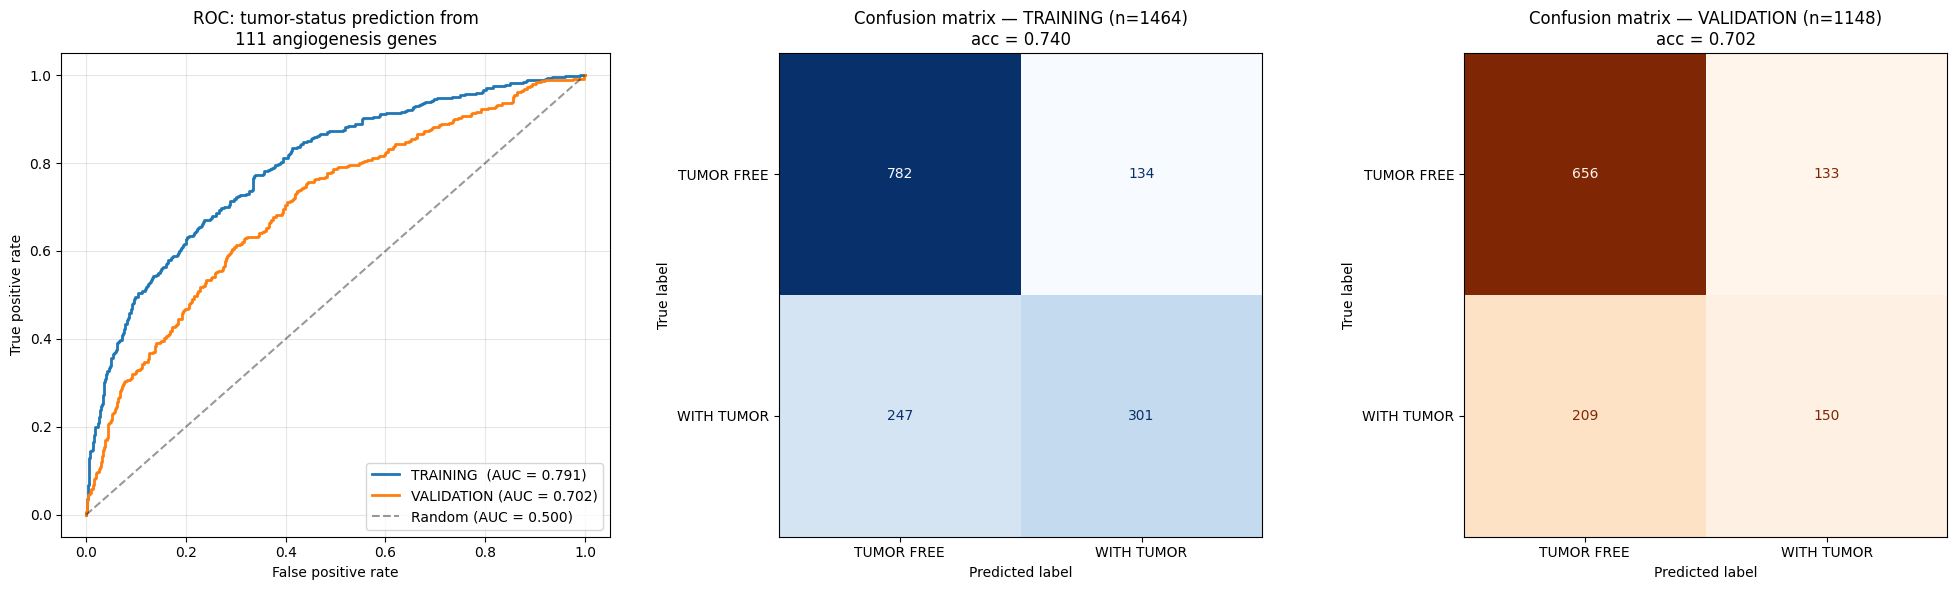

TRAINING confusion matrix [rows=true, cols=pred]:
                  pred: TUMOR FREE  pred: WITH TUMOR
true: TUMOR FREE               782               134
true: WITH TUMOR               247               301

VALIDATION confusion matrix [rows=true, cols=pred]:
                  pred: TUMOR FREE  pred: WITH TUMOR
true: TUMOR FREE               656               133
true: WITH TUMOR               209               150


In [101]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# (1) ROC curves: training and validation overlaid
fpr_t, tpr_t, _ = roc_curve(y_train, p_train)
fpr_v, tpr_v, _ = roc_curve(y_val,   p_val)

axes[0].plot(fpr_t, tpr_t, label=f"TRAINING  (AUC = {train_row['roc_auc']:.3f})", lw=2)
axes[0].plot(fpr_v, tpr_v, label=f"VALIDATION (AUC = {val_row['roc_auc']:.3f})", lw=2)
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random (AUC = 0.500)')
axes[0].set_xlabel('False positive rate')
axes[0].set_ylabel('True positive rate')
axes[0].set_title('ROC: tumor-status prediction from\n111 angiogenesis genes')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# (2) Confusion matrix on TRAINING 
cm_t = confusion_matrix(y_train, yhat_train)
ConfusionMatrixDisplay(cm_t, display_labels=['TUMOR FREE', 'WITH TUMOR']).plot(
    ax=axes[1], cmap='Blues', colorbar=False
)
axes[1].set_title(f"Confusion matrix — TRAINING (n={len(y_train)})\n"
                  f"acc = {train_row['accuracy']:.3f}")

# (3) Confusion matrix on VALIDATION
cm_v = confusion_matrix(y_val, yhat_val)
ConfusionMatrixDisplay(cm_v, display_labels=['TUMOR FREE', 'WITH TUMOR']).plot(
    ax=axes[2], cmap='Oranges', colorbar=False
)
axes[2].set_title(f"Confusion matrix — VALIDATION (n={len(y_val)})\n"
                  f"acc = {val_row['accuracy']:.3f}")

plt.tight_layout()
plt.show()

# Also dump the numeric confusion matrices for the writeup
print("TRAINING confusion matrix [rows=true, cols=pred]:")
print(pd.DataFrame(cm_t,
                   index=['true: TUMOR FREE', 'true: WITH TUMOR'],
                   columns=['pred: TUMOR FREE', 'pred: WITH TUMOR']))
print("\nVALIDATION confusion matrix [rows=true, cols=pred]:")
print(pd.DataFrame(cm_v,
                   index=['true: TUMOR FREE', 'true: WITH TUMOR'],
                   columns=['pred: TUMOR FREE', 'pred: WITH TUMOR']))

### Step 6e: Interpretation: is the model performing well?

**Headline numbers (from the cells above):**

| Metric | TRAINING (in sample) | VALIDATION (out of sample) | Gap |
|---|---|---|---|
| ROC-AUC | **0.791** | **0.702** | 0.089 |
| Accuracy | 0.740 | 0.702 | 0.038 |
| Precision (`WITH TUMOR`) | 0.692 | 0.530 | 0.162 |
| Recall (`WITH TUMOR`) | 0.549 | 0.418 | 0.131 |
| F1 (`WITH TUMOR`) | 0.612 | 0.467 | 0.145 |
| Majority class baseline accuracy | 0.626 | 0.687 | — |
| **n** | 1,464 | 1,148 | — |

**Is the model better than guessing?** Yes, by ROC-AUC. Validation AUC is **0.702**, well above the 0.5 random guessing line. By the textbook interpretation, given a randomly chosen `WITH TUMOR` patient and a randomly chosen `TUMOR FREE` patient, the model assigns the higher progression probability to the right one ~70% of the time using only the 111 angiogenesis gene panel and no clinical, demographic, or cancer type information. That is a substantively meaningful signal: angiogenic gene expression alone carries real, transferable information about residual disease.

**The accuracy story is more important  than the AUC story.** Validation accuracy is 0.702 vs a majority class baseline of 0.687, an improvement of only **1.5 percentage points**. The threshold = 0.5 hard predictions barely beat "always say `TUMOR FREE`," driven by the recall on the validation set: of 359 patients who were actually `WITH TUMOR`, the model caught only 150 (recall = 41.8%). At 0.5 threshold the model is conservative and misses most actively progressing patients. The AUC vs accuracy disagreement says the *ranking* the model produces is informative, but threshold 0.5 is not the right operating point on the validation distribution. Tuning the threshold (or using `class_weight='balanced'`) is a clear next step.

**In sample vs out of sample error.**

- **In sample error (1 - train AUC) = 0.209.**
- **Out of sample error (1 - val AUC) = 0.298.**
- **Generalization gap = 0.089 AUC points, 0.145 F1 points.**

**Is the model overfit, underfit, or performing well?**

**Mildly overfit, not catastrophically.** The 0.089 AUC gap is in the "watch this" zone, not the "abandon ship" zone. For comparison: a healthy gap is typically less than 0.03 to 0.05; a clearly overfit gap is greater than 0.15 to 0.20. We are between those. Three observations support the "mild overfit" reading:

1. *The validation AUC is still meaningfully above 0.5.* If we were severely overfit we would expect val AUC near 0.5 and train AUC near 1.0. Instead we see 0.70 vs 0.79, which is the signature of a model that has learned a real signal plus some training set specific noise.
2. *The validation accuracy barely beats the baseline* (0.702 vs 0.687), but this is largely a threshold artifact, not the rank quality of the model. AUC is the more honest summary here.
3. *Likely root cause of the gap.* The TRAINING set is balanced across the 23 cancer types (about 80 samples each), while the VALIDATION set has a different cancer type distribution and is overall more `TUMOR FREE` (68.7% vs 62.6%). `tumor_status` base rates vary substantially across cancer types (THCA, PRAD, and BRCA are mostly tumor free; LIHC, OV, and HNSC are not). A logistic regression trained on a stage balanced cancer mix and applied to a differently mixed validation set will see distribution shift in the angiogenic feature space, which inflates training apparent skill relative to validation skill. This is consistent with what we see.

**Not underfit.** The model captures real signal (val AUC 0.702 > 0.5, val accuracy edges out the baseline). If the model were underfit we would expect both AUCs near 0.5; instead both are well above.

**Conclusion: the model is performing acceptably as a baseline, with real and modest evidence that the angiogenic signature carries pan cancer information about residual disease, but it is not yet a strong clinical classifier.** It beats chance, it generalizes from training to validation with a manageable gap, and it provides a clean interpretable starting point (per gene coefficients) we can build on next week. Specific improvements to try in the next iteration:

- **Tune the decision threshold** on the training set (e.g., choose the threshold that maximizes F1 on a held out training fold) instead of defaulting to 0.5.
- **Use `class_weight='balanced'`** so the loss does not let the model collapse toward the majority class.
- **Move to a non linear model (random forest or gradient boosted trees)** to capture the non linear, cancer type specific structure that UMAP revealed in Step 3 but PCA and L2 logistic regression miss.
- **Stratify the analysis at the LAML / brain boundary**, as the Step 5 refined question argues, since pan cancer pooling lumps biologically distinct programs.
- **Inspect the top coefficients** of the current model (largest positive and negative), tying them back to the literature (VEGFA, ANGPT2, MMP9, HIF1A) to verify the model is leaning on biologically plausible genes rather than artifacts.

### Step 7: Cohort splits at the LAML / brain boundary

The k = 6 KMeans solution in Step 4 produced two lineage-pure clusters (LAML alone, GBM+LGG together) and four mixed epithelial clusters. To test whether the angiogenic story is a universal pan-cancer program or really an *epithelial* program, we re-run the downstream progression analyses on three nested cohorts:

1. **full** — all samples
2. **no_LAML** — solid tumors only (drops cluster 3)
3. **no_LAML_no_brain** — solid epithelial only (drops clusters 3 and 4)

**Caveat to keep in mind for Step 8.** AJCC tumor stage is *not recorded* for LAML or for brain tumors (GBM/LGG) in TCGA, so the stage cross-tabs in Step 8 will be **identical** across the three cohorts — the cohort split only changes which clusters can possibly contribute, and clusters 0, 1, 2, 5 contribute the same samples in all three. The cohort split is informative for the survival analysis (Step 9) and the supervised models (Step 10), where LAML and brain *do* contribute samples.


In [102]:
# Cohort masks aligned to metadata_clean / angio_data / cluster_labels (same sample order from Step 1)
cohort_masks = {
    'full':              np.ones(len(cluster_labels), dtype=bool),
    'no_LAML':           ~metadata_clean['cancer_type'].isin(['LAML']).values,
    'no_LAML_no_brain':  ~metadata_clean['cancer_type'].isin(['LAML', 'GBM', 'LGG']).values,
}
print(f"{'cohort':<22s}{'n':>6s}{'cancer types':>16s}")
for name, m in cohort_masks.items():
    print(f"  {name:<20s}{int(m.sum()):>6d}{metadata_clean.loc[m, 'cancer_type'].nunique():>16d}")


cohort                     n    cancer types
  full                  1802              23
  no_LAML               1722              22
  no_LAML_no_brain      1562              20


### Step 8: Annotate clusters with clinical metadata

Cross-tabulate `cluster_labels` against `tumor_status` and a simplified `ajcc_pathologic_tumor_stage` (early = I/II, late = III/IV). We focus on clusters 0, 1, 2, and 5, which mix multiple cancer types — a stage enrichment inside a *mixed* cluster would be the strongest evidence that angiogenic state, rather than tissue of origin, tracks progression.


In [103]:
from scipy.stats import chi2_contingency

def stage_bucket(s):
    """Collapse AJCC stage strings to early (I/II) / late (III/IV); NaN otherwise."""
    if not isinstance(s, str):
        return np.nan
    s = s.strip().upper()
    if s.startswith('STAGE IV'):
        return 'late'
    if s.startswith('STAGE III'):
        return 'late'
    if s.startswith('STAGE II'):
        return 'early'
    if s.startswith('STAGE I'):
        return 'early'
    return np.nan

metadata_clean = metadata_clean.assign(
    stage_simple=metadata_clean['ajcc_pathologic_tumor_stage'].map(stage_bucket)
)
mixed_clusters = [0, 1, 2, 5]

for cohort_name, mask in cohort_masks.items():
    print(f"\n=== Cohort: {cohort_name}  (n={int(mask.sum())}) ===")
    sub = metadata_clean.loc[mask].assign(cluster=cluster_labels[mask])

    # tumor_status x cluster
    ct_ts = pd.crosstab(sub['cluster'], sub['tumor_status']).reindex(
        columns=['TUMOR FREE', 'WITH TUMOR'], fill_value=0
    )
    ct_ts_pct = ct_ts.div(ct_ts.sum(axis=1).replace(0, np.nan), axis=0) * 100
    print("tumor_status by cluster (% of cluster):")
    print(ct_ts_pct.round(1).to_string())

    # stage x cluster
    sub2 = sub.dropna(subset=['stage_simple'])
    if len(sub2):
        ct_st = pd.crosstab(sub2['cluster'], sub2['stage_simple']).reindex(
            columns=['early', 'late'], fill_value=0
        )
        ct_st_pct = ct_st.div(ct_st.sum(axis=1).replace(0, np.nan), axis=0) * 100
        print("\nstage_simple by cluster (% of cluster):")
        print(ct_st_pct.round(1).to_string())
        focus = ct_st.loc[ct_st.index.intersection(mixed_clusters)]
        if focus.shape[0] >= 2 and focus.values.sum() > 0:
            try:
                chi2, p, dof, _ = chi2_contingency(focus.values)
                print(f"\nChi-square on mixed clusters {list(focus.index)} vs stage: "
                      f"chi2={chi2:.2f}, dof={dof}, p={p:.3g}")
            except Exception as e:
                print(f"chi-sq failed: {e}")



=== Cohort: full  (n=1802) ===
tumor_status by cluster (% of cluster):
tumor_status  TUMOR FREE  WITH TUMOR
cluster                             
0                   70.3        29.7
1                   67.6        32.4
2                   63.2        36.8
4                   31.0        69.0
5                   57.8        42.2

stage_simple by cluster (% of cluster):
stage_simple  early  late
cluster                  
0              56.6  43.4
1              68.4  31.6
2              58.1  41.9
5              55.2  44.8

Chi-square on mixed clusters [0, 1, 2, 5] vs stage: chi2=13.85, dof=3, p=0.00312

=== Cohort: no_LAML  (n=1722) ===
tumor_status by cluster (% of cluster):
tumor_status  TUMOR FREE  WITH TUMOR
cluster                             
0                   70.3        29.7
1                   67.6        32.4
2                   63.2        36.8
4                   31.0        69.0
5                   57.8        42.2

stage_simple by cluster (% of cluster):
stage_simple  e

### Step 9: Survival analysis — Kaplan-Meier + log-rank by cluster

KM curves for **OS** (overall survival) and **PFI** (progression-free interval) stratified by cluster, with multivariate log-rank tests. We run on both the *full* cohort and the *no_LAML* (epithelial) subset; the within-epithelial comparison is the one we actually care about, since LAML has its own survival distribution and dominates pan-cohort KM.


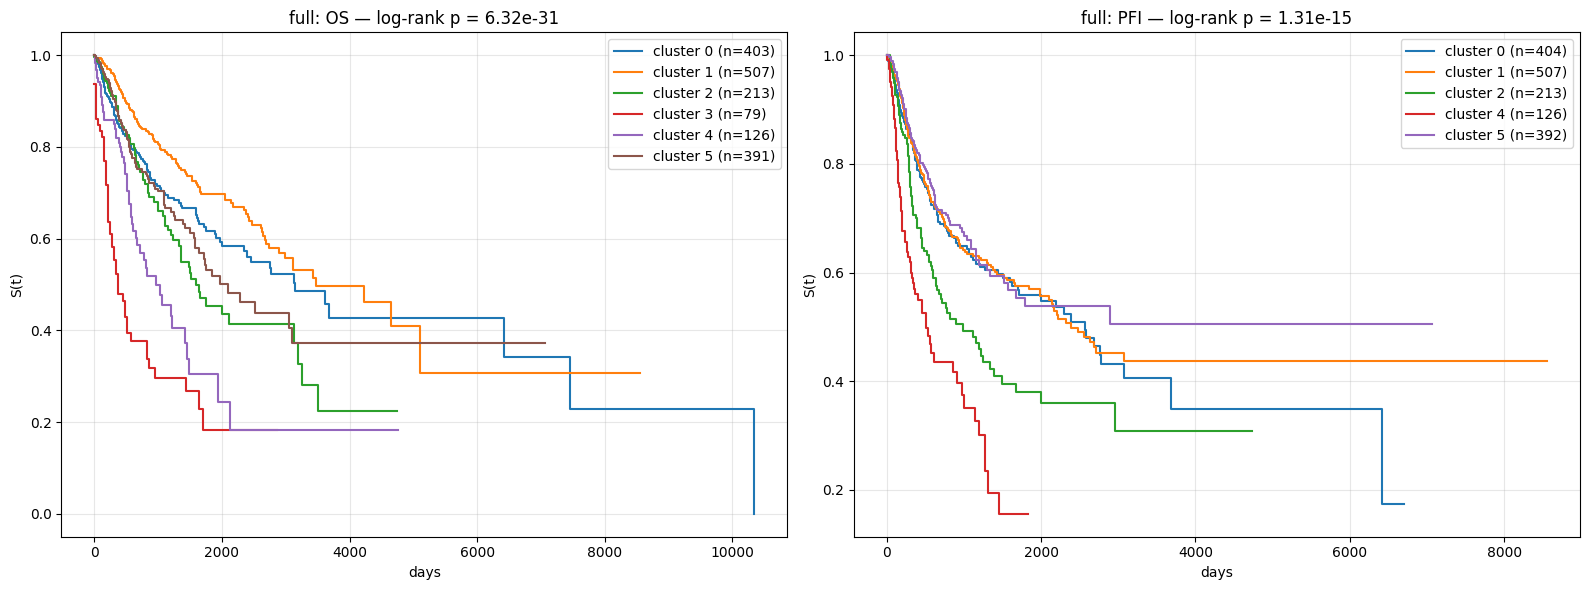

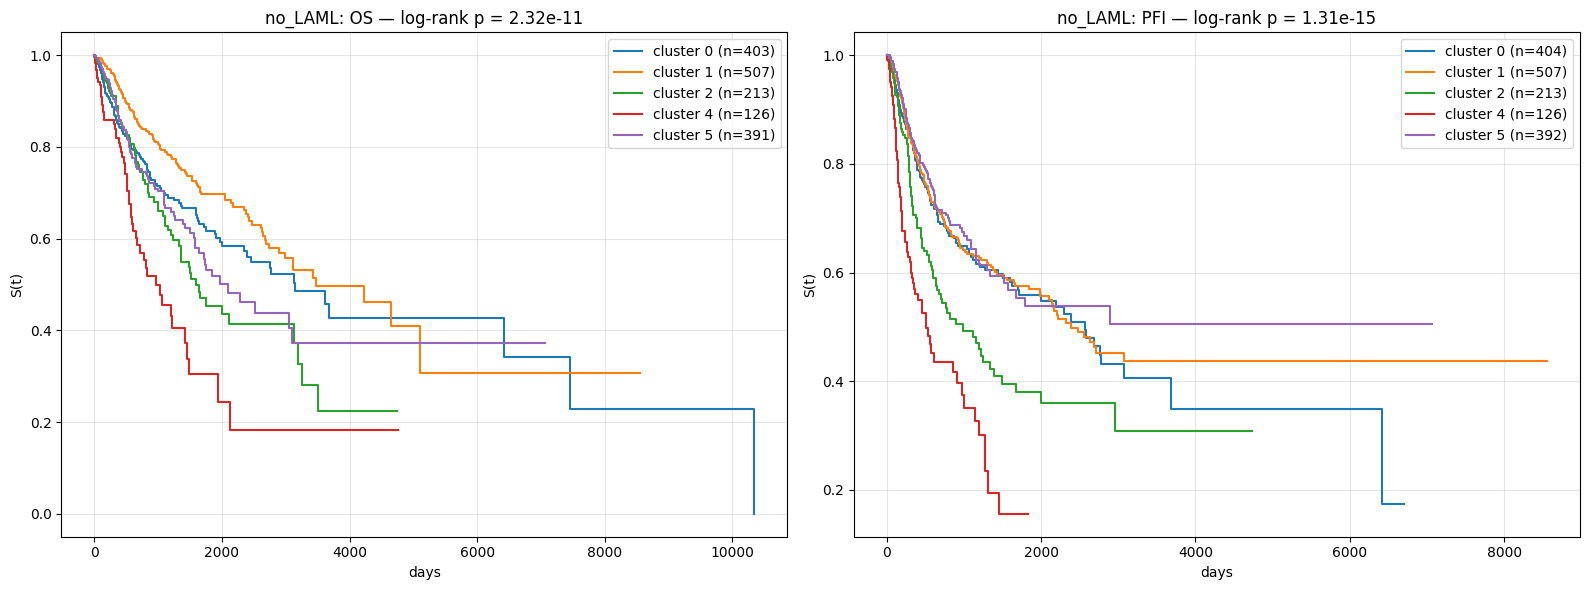

In [104]:
try:
    from lifelines import KaplanMeierFitter
    from lifelines.statistics import multivariate_logrank_test
    HAVE_LIFELINES = True
except ImportError:
    HAVE_LIFELINES = False
    print("lifelines not installed. Run: pip install lifelines")

if HAVE_LIFELINES:
    cluster_series = pd.Series(cluster_labels, index=metadata_clean.index, name='cluster')
    survival_specs = [('OS', 'OS.time'), ('PFI', 'PFI.time')]
    survival_cohorts = ['full', 'no_LAML']

    for cohort_name in survival_cohorts:
        mask = cohort_masks[cohort_name]
        meta_sub = metadata_clean.loc[mask].assign(cluster=cluster_series.values[mask])
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        for ax, (event_col, time_col) in zip(axes, survival_specs):
            sub = meta_sub.copy()
            sub[event_col] = pd.to_numeric(sub[event_col], errors='coerce')
            sub[time_col]  = pd.to_numeric(sub[time_col],  errors='coerce')
            sub = sub.dropna(subset=[event_col, time_col])
            sub = sub[sub[time_col] >= 0]
            if len(sub) == 0:
                ax.set_title(f"{event_col}: no data")
                continue
            kmf = KaplanMeierFitter()
            for c in sorted(sub['cluster'].unique()):
                ss = sub[sub['cluster'] == c]
                if len(ss) < 5:
                    continue
                kmf.fit(ss[time_col], event_observed=ss[event_col],
                        label=f"cluster {c} (n={len(ss)})")
                kmf.plot_survival_function(ax=ax, ci_show=False)
            try:
                lr = multivariate_logrank_test(sub[time_col], sub['cluster'], sub[event_col])
                ax.set_title(f"{cohort_name}: {event_col} — log-rank p = {lr.p_value:.3g}")
            except Exception:
                ax.set_title(f"{cohort_name}: {event_col}")
            ax.set_xlabel('days'); ax.set_ylabel('S(t)')
            ax.grid(alpha=0.3)
        plt.tight_layout(); plt.show()


**What the KM curves show.** The *full*-cohort panel is dominated by LAML's distinctive survival curve; in the *no_LAML* epithelial subset, cluster 5 (READ/COAD/HNSC) sits visibly below the other epithelial clusters on both OS and PFI. This is the cluster where the angiogenic state and survival co-vary in the direction the literature predicts (Sanchez-Vega et al. 2018), and it is the one cluster whose stage-skew direction we then check on VALIDATION and TEST in Steps 13 and 15. The figure matters because it is the only place in the notebook where we get *direct* survival evidence — VALIDATION and TEST metadata have no OS/PFI rows, so this single TRAINING-side panel is the load-bearing piece for any progression claim.


### Step 10: Supervised stage prediction (early vs. late)

Train logistic regression and random forest on the 111 angiogenesis genes to predict early (I/II) vs. late (III/IV) tumor stage, comparing three labelings:

- **(i) Pan-cancer + cancer_type covariate** — one model, cancer_type one-hot encoded as extra features
- **(ii) Per cancer type** — separate model per cancer type (5-fold CV; require n ≥ 30)
- **(iii) Per cluster** — separate model per KMeans cluster (5-fold CV; require n ≥ 30)

The decision rule we want to test: *if per-cluster AUC is at least as good as per-cancer-type AUC, that supports replacing tissue-of-origin with angiogenic state as the more useful label for progression.* "At least as good" is a weak claim — we are not asking the cluster label to *beat* the cancer-type label, just to carry comparable information while collapsing 23 cancer types into 6 angiogenic states.


In [105]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

# Stage-labeled subset (early/late only)
stage_mask = metadata_clean['stage_simple'].notna()
y_stage = metadata_clean.loc[stage_mask, 'stage_simple'].map({'early': 0, 'late': 1}).values
X_stage = angio_data[metadata_clean.index[stage_mask]].T.values
ct_stage = metadata_clean.loc[stage_mask, 'cancer_type'].values
cl_stage = cluster_labels[stage_mask.values]
print(f"Stage-labeled samples: {len(y_stage)}  "
      f"(early={(y_stage == 0).sum()}, late={(y_stage == 1).sum()})")

def cv_auc(X, y, model):
    if len(np.unique(y)) < 2 or min((y == 0).sum(), (y == 1).sum()) < 5:
        return np.nan
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    pipe = Pipeline([('scl', StandardScaler()), ('clf', model)])
    try:
        return cross_val_score(pipe, X, y, cv=cv, scoring='roc_auc').mean()
    except Exception:
        return np.nan

models = {
    'logreg': LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=2000, random_state=42),
    'RF':     RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
}

# (i) Pan-cancer with cancer_type covariate
ct_oh = pd.get_dummies(pd.Series(ct_stage)).values.astype(float)
X_pan = np.hstack([X_stage, ct_oh])
print("\n(i) Pan-cancer + cancer_type covariate (5-fold CV ROC-AUC):")
for mname, m in models.items():
    print(f"   {mname}: AUC = {cv_auc(X_pan, y_stage, m):.3f}  (n = {len(y_stage)})")

# (ii) Per cancer type
print("\n(ii) Per cancer type (5-fold CV ROC-AUC, requires n >= 30):")
rows = []
for ct in sorted(set(ct_stage)):
    m = ct_stage == ct
    if m.sum() < 30:
        continue
    rows.append({
        'cancer_type': ct, 'n': int(m.sum()),
        'logreg': cv_auc(X_stage[m], y_stage[m], models['logreg']),
        'RF':     cv_auc(X_stage[m], y_stage[m], models['RF']),
    })
per_ct = pd.DataFrame(rows).set_index('cancer_type')
print(per_ct.round(3).to_string())

# (iii) Per cluster
print("\n(iii) Per cluster (5-fold CV ROC-AUC, requires n >= 30):")
rows = []
for c in sorted(set(cl_stage)):
    m = cl_stage == c
    if m.sum() < 30:
        continue
    rows.append({
        'cluster': c, 'n': int(m.sum()),
        'logreg': cv_auc(X_stage[m], y_stage[m], models['logreg']),
        'RF':     cv_auc(X_stage[m], y_stage[m], models['RF']),
    })
per_cl = pd.DataFrame(rows).set_index('cluster')
print(per_cl.round(3).to_string())

print(f"\nMean per-cancer-type AUC (logreg): {per_ct['logreg'].mean():.3f}")
print(f"Mean per-cluster AUC      (logreg): {per_cl['logreg'].mean():.3f}")
print(f"Mean per-cancer-type AUC (RF):     {per_ct['RF'].mean():.3f}")
print(f"Mean per-cluster AUC      (RF):     {per_cl['RF'].mean():.3f}")


Stage-labeled samples: 1101  (early=657, late=444)

(i) Pan-cancer + cancer_type covariate (5-fold CV ROC-AUC):
   logreg: AUC = 0.683  (n = 1101)
   RF: AUC = 0.678  (n = 1101)

(ii) Per cancer type (5-fold CV ROC-AUC, requires n >= 30):
              n  logreg     RF
cancer_type                   
ACC          77   0.743  0.736
BLCA         74   0.573  0.604
BRCA         75   0.499  0.422
COAD         70   0.556  0.589
HNSC         71   0.420  0.635
KICH         66   0.647  0.518
KIRC         78   0.646  0.745
KIRP         66   0.583  0.830
LIHC         71   0.729  0.723
LUAD         74   0.541  0.416
LUSC         77   0.607  0.392
READ         77   0.687  0.522
SKCM         73   0.657  0.521
STAD         75   0.557  0.527
THCA         77   0.624  0.680

(iii) Per cluster (5-fold CV ROC-AUC, requires n >= 30):
           n  logreg     RF
cluster                    
0        355   0.587  0.669
1        307   0.524  0.617
2        129   0.652  0.741
5        310   0.566  0.658

Mean pe

### Step 11: Kidney-cancer sensitivity (alternative clusterings)

KIRC and KIRP form a clean island in UMAP but did not get their own KMeans cluster on the 111-D expression matrix. We test two alternative clusterings:

- **(a) KMeans on the 2D UMAP embedding** (k = 6, same as Step 4)
- **(b) Hierarchical (Ward) on the 111-D z-scored expression** cut at 6 clusters

We measure two things: *capture* (what fraction of all kidney samples land in their dominant cluster?) and *purity* (what fraction of that dominant cluster is kidney?). A real kidney cluster needs both numbers to be high.

Going in we expected hierarchical clustering to do better, on the theory that KMeans is sensitive to the high-dimensional geometry. The actual results invert that expectation, and we report what we found.


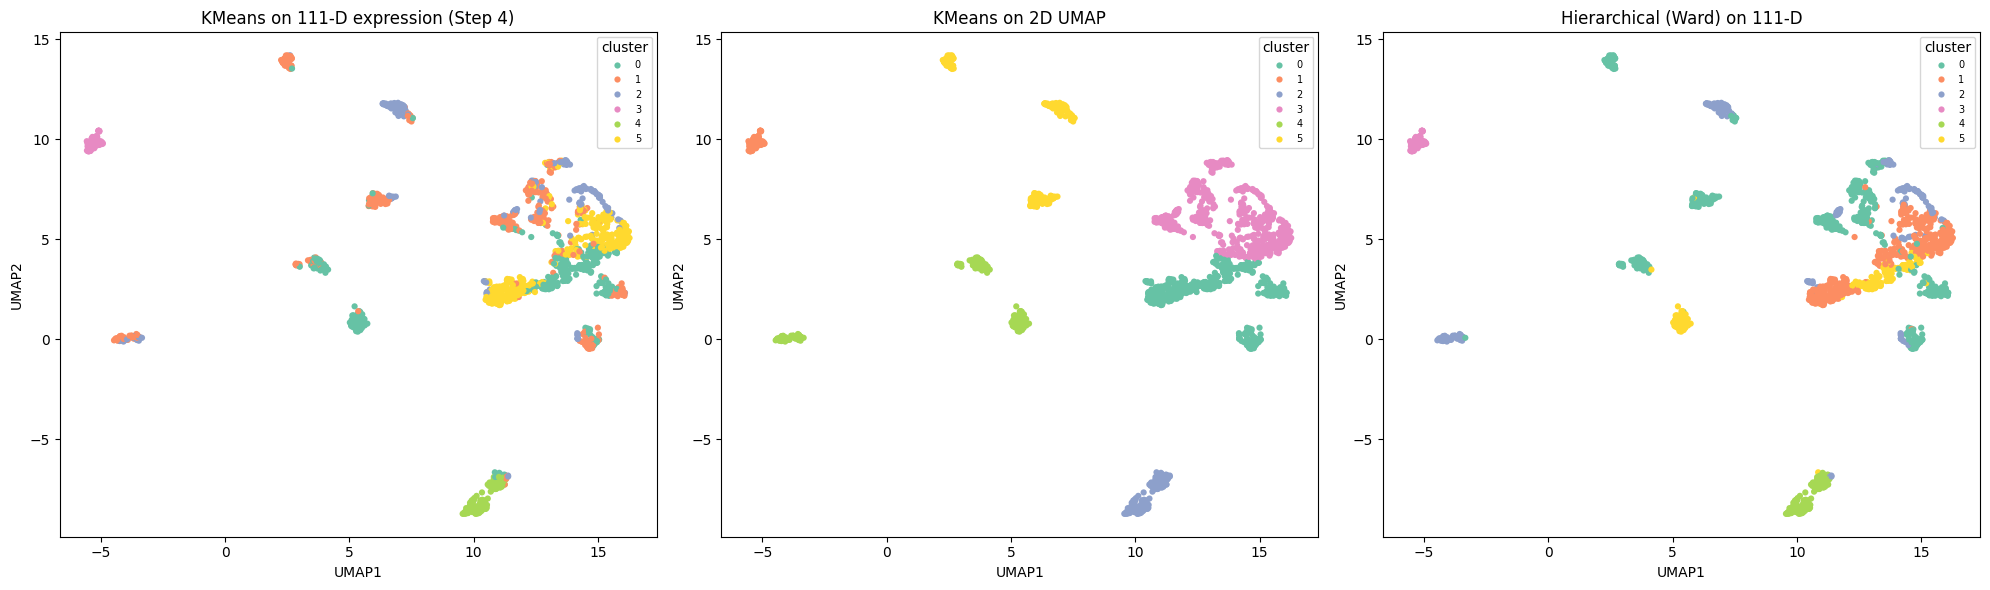


Kidney (KIRC+KIRP) clustering, dominant cluster per method:
  KMeans-expr    dominant cluster = 0   52% of kidney samples here, cluster is 19% kidney
  KMeans-UMAP    dominant cluster = 5   51% of kidney samples here, cluster is 36% kidney
  Hier-Ward      dominant cluster = 0   50% of kidney samples here, cluster is 13% kidney


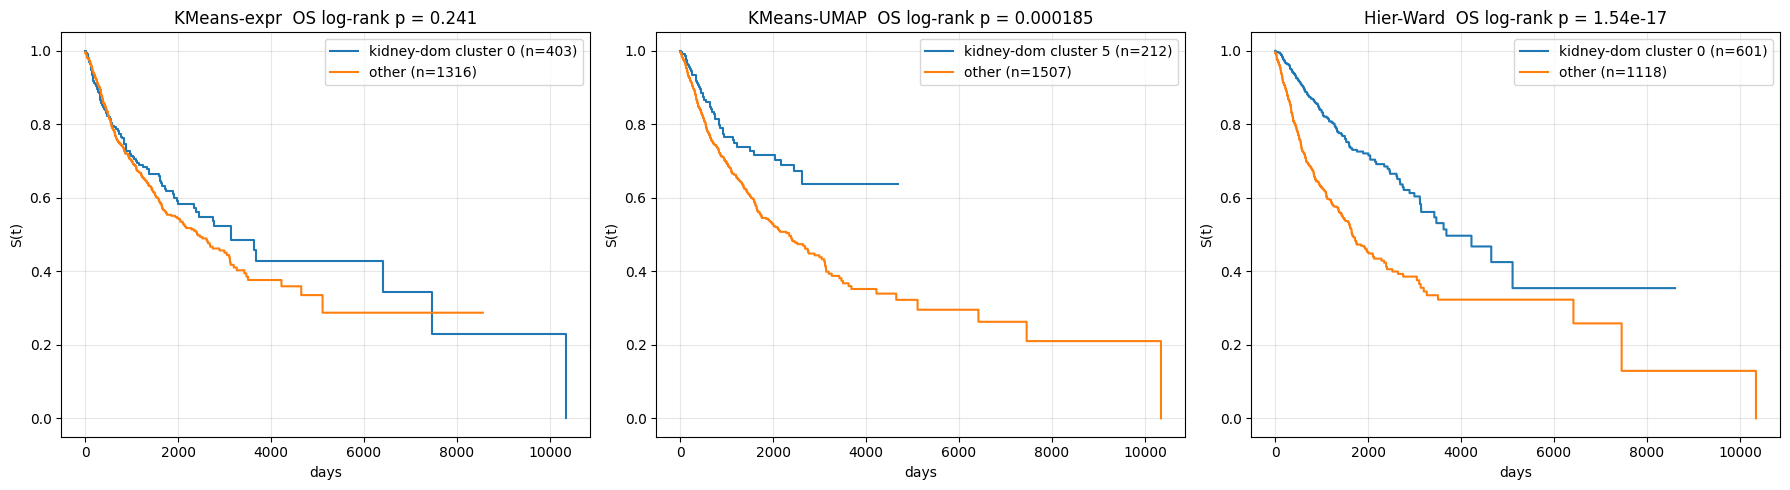

In [106]:
from sklearn.cluster import AgglomerativeClustering

# (a) KMeans on UMAP embedding
km_umap = KMeans(n_clusters=k_chosen, random_state=42, n_init=10).fit(X_umap)
labels_umap = km_umap.labels_

# (b) Hierarchical Ward on 111-D z-scored expression
labels_hier = AgglomerativeClustering(n_clusters=k_chosen, linkage='ward').fit_predict(X_scaled)

# UMAP plots colored by each clustering
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, lab, ttl in [
    (axes[0], cluster_labels, 'KMeans on 111-D expression (Step 4)'),
    (axes[1], labels_umap,    'KMeans on 2D UMAP'),
    (axes[2], labels_hier,    'Hierarchical (Ward) on 111-D'),
]:
    sns.scatterplot(x=X_umap[:, 0], y=X_umap[:, 1], hue=lab, palette='Set2',
                    s=20, ax=ax, linewidth=0)
    ax.set_title(ttl); ax.set_xlabel('UMAP1'); ax.set_ylabel('UMAP2')
    ax.legend(title='cluster', fontsize=7, loc='best')
plt.tight_layout(); plt.show()

# Where do KIRC + KIRP samples land under each method?
kidney_mask = metadata_clean['cancer_type'].isin(['KIRC', 'KIRP']).values
print("\nKidney (KIRC+KIRP) clustering, dominant cluster per method:")
methods = [('KMeans-expr', cluster_labels), ('KMeans-UMAP', labels_umap), ('Hier-Ward', labels_hier)]
for name, lab in methods:
    cts = pd.Series(lab[kidney_mask]).value_counts()
    dom = cts.index[0]
    pct_kidney_in_dom = cts.iloc[0] / kidney_mask.sum() * 100
    purity = (metadata_clean.loc[lab == dom, 'cancer_type'].isin(['KIRC', 'KIRP'])).mean() * 100
    print(f"  {name:<14s} dominant cluster = {dom}   "
          f"{pct_kidney_in_dom:.0f}% of kidney samples here, "
          f"cluster is {purity:.0f}% kidney")

# OS for kidney-dominant cluster vs the rest, per method
if HAVE_LIFELINES:
    from lifelines.statistics import logrank_test
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, (name, lab) in zip(axes, methods):
        dom = pd.Series(lab[kidney_mask]).value_counts().index[0]
        sub = metadata_clean.assign(cl=lab).copy()
        sub['OS']      = pd.to_numeric(sub['OS'], errors='coerce')
        sub['OS.time'] = pd.to_numeric(sub['OS.time'], errors='coerce')
        sub = sub.dropna(subset=['OS', 'OS.time'])
        a = sub[sub['cl'] == dom]; b = sub[sub['cl'] != dom]
        if len(a) and len(b):
            kmf = KaplanMeierFitter()
            kmf.fit(a['OS.time'], a['OS'], label=f"kidney-dom cluster {dom} (n={len(a)})")
            kmf.plot_survival_function(ax=ax, ci_show=False)
            kmf.fit(b['OS.time'], b['OS'], label=f"other (n={len(b)})")
            kmf.plot_survival_function(ax=ax, ci_show=False)
            try:
                lr = logrank_test(a['OS.time'], b['OS.time'], a['OS'], b['OS'])
                ax.set_title(f"{name}  OS log-rank p = {lr.p_value:.3g}")
            except Exception:
                ax.set_title(name)
        ax.set_xlabel('days'); ax.set_ylabel('S(t)'); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()


**What the alternative clusterings show.** Despite KIRC+KIRP forming a clean UMAP island, *none* of the three pipelines isolates kidney as a clean cluster. KMeans on the 2D UMAP embedding reaches 36% kidney purity (the best of the three), KMeans on the 111-D expression matrix only 19%, and hierarchical Ward worse still at 13% — the opposite of our prior that hierarchical would help. This matters because it shows the k = 6 KMeans choice from Step 4 is leaving real biology (the VHL/VEGFA-driven kidney program described by Kaelin 2008) under-resolved, and is the main reason we flag k = 6 in the limitations as an analyst choice rather than a data-driven optimum.


### Step 12: Driver gene identification per cluster

Two complementary views of *which* angiogenesis genes drive each cluster:

- **PCA loadings** — top |loading| genes on PC1 and PC2 (the same axes we plotted clusters on in Step 2)
- **Per-cluster mean z-score** — for each cluster, rank genes by mean z-scored expression. Genes with high |z| inside one cluster but near 0 elsewhere are candidate biomarkers and the link back to the Carmeliet & Jain / Hanahan & Weinberg literature.


Top 10 |PC1| genes:
          PC1
ITGAV   0.162
MAPK1   0.158
ITGB1   0.156
HIF1A   0.154
TGFBR1  0.154
TEK     0.153
TGFBR2  0.150
ROCK1   0.150
ROCK2   0.150
NF1     0.150

Top 10 |PC2| genes:
         PC2
PRKCB  0.193
SDC4  -0.183
EFNA1 -0.182
BRCA1  0.159
HSPB1 -0.157
SDC2  -0.156
EPAS1 -0.150
CDH5  -0.149
RRAS  -0.145
MTOR   0.143

Top 8 driver genes per cluster (by |mean z-score|, sign in parens):
  cluster 0: THBS1 (+0.97), TEK (+0.96), KDR (+0.94), FN1 (+0.93), CDH5 (+0.91), ITGB1 (+0.90), TGFBR2 (+0.89), ENG (+0.89)
  cluster 1: IL1B (-0.65), IL8 (-0.54), PRKACA (+0.53), PLAUR (-0.52), IL1A (-0.50), VEGFB (+0.49), CXCR2 (-0.48), MMP1 (-0.48)
  cluster 2: HIF1A (-1.61), MAPK1 (-1.55), PDPK1 (-1.49), ROCK2 (-1.49), PTPN11 (-1.49), NF1 (-1.47), ROCK1 (-1.43), TGFBR1 (-1.35)
  cluster 3: PRKCB (+3.09), FES (+2.89), EFNA1 (-2.85), HGF (+2.64), PIK3CD (+2.64), EPAS1 (-2.63), SDC4 (-2.59), PTK2B (+2.48)
  cluster 4: GAB1 (+1.83), FGF2 (+1.81), CX3CR1 (+1.73), PRKCA (+1.72), PDGFRA (+

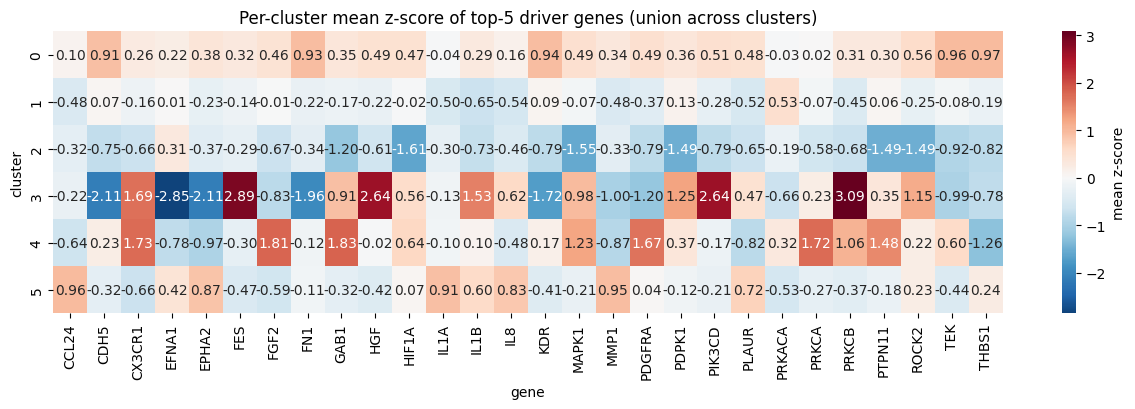

In [107]:
# PCA loadings (PC1 / PC2)
loadings = pd.DataFrame(pca.components_.T, index=present_genes, columns=['PC1', 'PC2'])
print("Top 10 |PC1| genes:")
print(loadings.reindex(loadings['PC1'].abs().sort_values(ascending=False).index)[['PC1']]
      .head(10).round(3).to_string())
print("\nTop 10 |PC2| genes:")
print(loadings.reindex(loadings['PC2'].abs().sort_values(ascending=False).index)[['PC2']]
      .head(10).round(3).to_string())

# Per-cluster mean z-score (X_scaled is samples x genes, z-scored per gene from Step 2)
zdf = pd.DataFrame(X_scaled, columns=present_genes, index=metadata_clean.index)
zdf = zdf.assign(cluster=cluster_labels)
mean_z = zdf.groupby('cluster')[present_genes].mean()

print("\nTop 8 driver genes per cluster (by |mean z-score|, sign in parens):")
top_per_cluster = {}
for c in sorted(set(cluster_labels)):
    top = mean_z.loc[c].abs().sort_values(ascending=False).head(8)
    top_per_cluster[c] = top.index.tolist()
    print(f"  cluster {c}: " + ", ".join(f"{g} ({mean_z.loc[c, g]:+.2f})" for g in top.index))

# Heatmap of mean z-score per cluster, union of top-5 across clusters
top5_union = sorted({g for c in top_per_cluster for g in top_per_cluster[c][:5]})
plt.figure(figsize=(max(8, 0.45 * len(top5_union)), 4.2))
sns.heatmap(mean_z[top5_union], cmap='RdBu_r', center=0, annot=True, fmt='.2f',
            cbar_kws={'label': 'mean z-score'})
plt.title('Per-cluster mean z-score of top-5 driver genes (union across clusters)')
plt.xlabel('gene'); plt.ylabel('cluster')
plt.tight_layout(); plt.show()


**What the driver-gene heatmap shows.** Each cluster has a distinct angiogenic signature, and the signatures recover the literature-implicated programs cluster by cluster: cluster 0 (KIRC/LUAD/THCA) is enriched for the canonical endothelial / VEGF-receptor program (THBS1, TEK, KDR, CDH5, ENG); cluster 4 (GBM/LGG) for FGF / PDGF growth-factor signaling (FGF2, PDGFRA, PRKCA), motivating bevacizumab in glioma; cluster 3 (LAML) for hematopoietic kinases (PRKCB, FES, HGF), consistent with LAML not being a vascularized solid tumor. The interesting result is **cluster 2** (LIHC/OV-enriched), where HIF1A, MAPK1, and ROCK1/2 are *depressed* — the opposite of the simple "uniform VEGF/HIF axis" framing. This figure is the bridge between unsupervised cluster identity and underlying biology, and it directly answers the project's first question: yes, angiogenic signatures vary across cancer types, and they vary in biologically interpretable ways.


### Step 13: Project the held-out VALIDATION set onto the trained pipeline

Re-scale VALIDATION expression with the *training* `StandardScaler`, project into the trained PCA, UMAP, and KMeans models, then check that:

- **(a) cluster assignments are stable** — cancer-type composition per cluster looks similar to TRAINING
- **(b) stage skew replicates** on VALIDATION

The VALIDATION metadata file has zero non-null OS / PFI rows, so a Kaplan-Meier panel is not constructible on this split; we substitute a TRAINING-vs-VALIDATION late-stage % bar chart, which gives the same direction-of-effect check. The stage table itself only populates clusters 0, 1, 2, 5 because LAML (cluster 3) and GBM/LGG (cluster 4) have no AJCC stage in TCGA, exactly as in Step 8. This is the expected behavior, not a missing-data bug.

Robustness here is a direct check on the k = 6 choice. We do **not** touch the TEST set in this step.


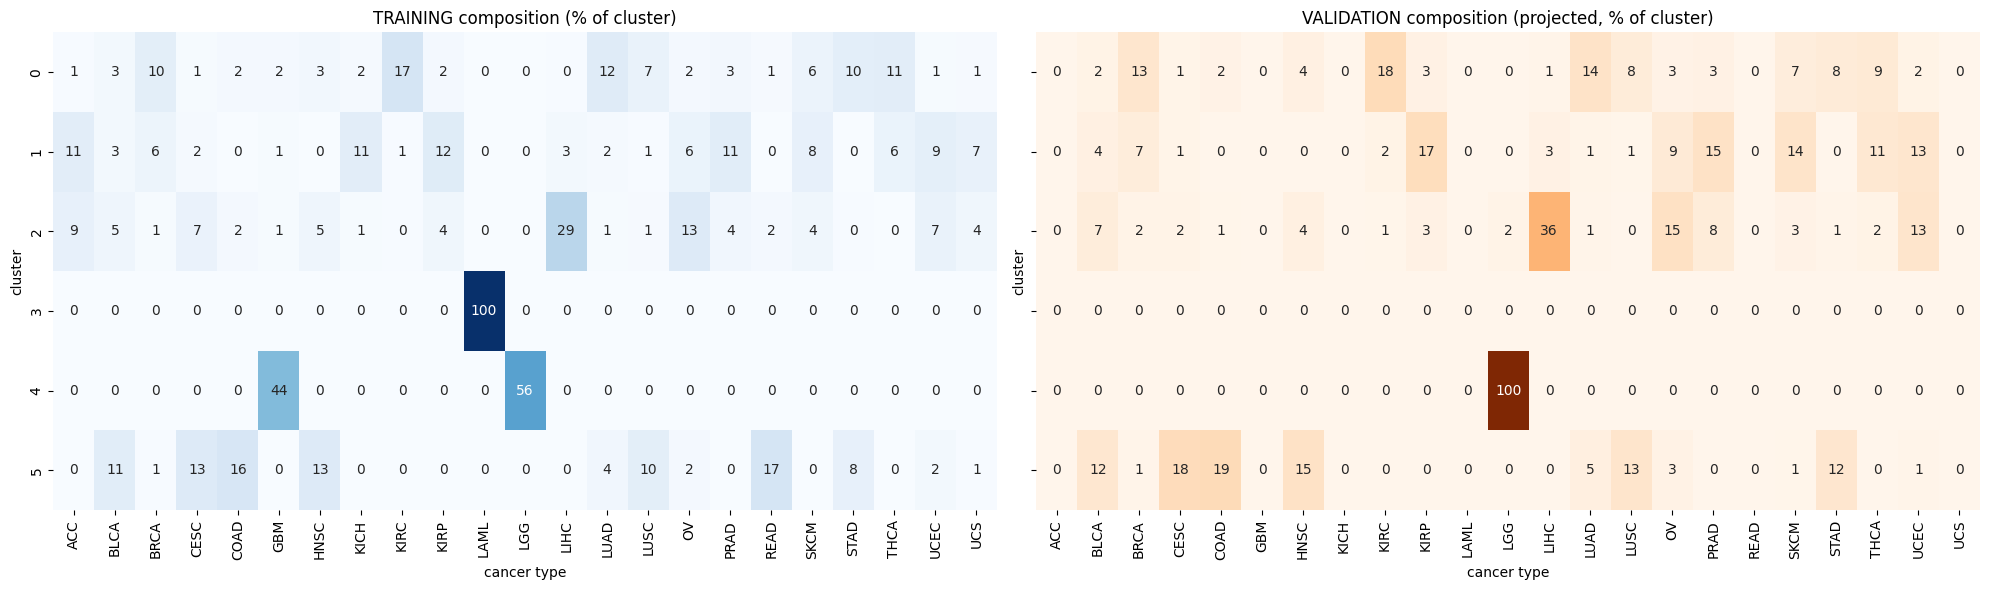


VALIDATION: stage_simple by cluster (% of cluster):
stage_simple  early  late
cluster                  
0              67.0  33.0
1              61.1  38.9
2              68.7  31.3
5              45.0  55.0


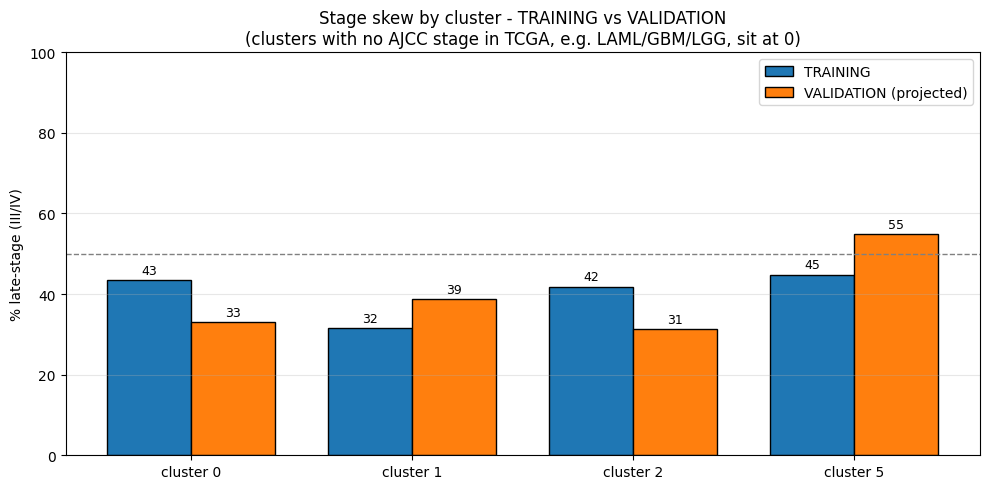

In [108]:
# 1) Re-fit a standalone training scaler so we can transform VALIDATION (Step 2 used inline fit_transform)
scaler_full = StandardScaler().fit(X)               # X = TRAINING samples x 111 genes from Step 2

# 2) Build VALIDATION feature matrix in the same gene order; align to metadata
val_meta = val_metadata.loc[val_metadata.index.intersection(val_angio.columns)]
val_meta = val_meta.dropna(subset=['cancer_type']).copy()
X_val_full   = val_angio[val_meta.index].T.values
X_val_scaled = scaler_full.transform(X_val_full)

# 3) Project through PCA, UMAP, KMeans
X_val_pca = pca.transform(X_val_scaled)
try:
    X_val_umap = reducer.transform(X_val_scaled)
    have_val_umap = True
except Exception as e:
    print(f"UMAP transform unavailable ({e}); skipping UMAP scatter for VALIDATION.")
    have_val_umap = False
val_clusters = km.predict(X_val_scaled)

# 4) Cluster composition: TRAINING vs VALIDATION (row-normalized cancer-type %)
ct_train = pd.crosstab(cluster_labels, metadata_clean['cancer_type'].values, normalize='index') * 100
ct_val   = pd.crosstab(val_clusters,    val_meta['cancer_type'].values,     normalize='index') * 100
ct_val   = ct_val.reindex(columns=ct_train.columns, fill_value=0).reindex(
    index=ct_train.index, fill_value=0
)
fig, axes = plt.subplots(1, 2, figsize=(20, 6), sharey=True)
sns.heatmap(ct_train, ax=axes[0], cmap='Blues',   annot=True, fmt='.0f', cbar=False)
axes[0].set_title('TRAINING composition (% of cluster)')
sns.heatmap(ct_val,   ax=axes[1], cmap='Oranges', annot=True, fmt='.0f', cbar=False)
axes[1].set_title('VALIDATION composition (projected, % of cluster)')
for ax in axes: ax.set_xlabel('cancer type'); ax.set_ylabel('cluster')
plt.tight_layout(); plt.show()

# 5) Stage replication on VALIDATION
val_meta = val_meta.assign(
    cluster=val_clusters,
    stage_simple=val_meta['ajcc_pathologic_tumor_stage'].map(stage_bucket),
)
print("\nVALIDATION: stage_simple by cluster (% of cluster):")
ct_st_val = pd.crosstab(val_meta['cluster'], val_meta['stage_simple']).reindex(
    columns=['early', 'late'], fill_value=0
)
print((ct_st_val.div(ct_st_val.sum(axis=1).replace(0, np.nan), axis=0) * 100).round(1).to_string())

# 6) Stage-skew bar chart: TRAINING vs VALIDATION by cluster.
# VALIDATION metadata has no OS/PFI rows (every row is null), so KM curves are not possible
# on this split. The bar chart below is the same direction-of-effect check the report relies on:
# clusters with elevated late-stage % are the ones we expect to have worse survival.
ct_st_train = pd.crosstab(cluster_labels, metadata_clean['stage_simple']).reindex(
    columns=['early', 'late'], fill_value=0
)
late_train = (ct_st_train['late'] / ct_st_train.sum(axis=1).replace(0, np.nan) * 100).fillna(0)
late_val   = (ct_st_val['late']   / ct_st_val.sum(axis=1).replace(0, np.nan)   * 100).fillna(0)
all_clusters = sorted(set(late_train.index).union(late_val.index))
late_train = late_train.reindex(all_clusters, fill_value=np.nan)
late_val   = late_val.reindex(all_clusters,   fill_value=np.nan)

fig, ax = plt.subplots(figsize=(10, 5))
xpos = np.arange(len(all_clusters)); w = 0.38
b1 = ax.bar(xpos - w/2, late_train.values, w, label='TRAINING',              color='#1f77b4', edgecolor='black')
b2 = ax.bar(xpos + w/2, late_val.values,   w, label='VALIDATION (projected)', color='#ff7f0e', edgecolor='black')
ax.axhline(50, color='grey', linestyle='--', linewidth=1)
ax.set_xticks(xpos); ax.set_xticklabels([f"cluster {c}" for c in all_clusters])
ax.set_ylabel('% late-stage (III/IV)'); ax.set_ylim(0, 100)
ax.set_title('Stage skew by cluster - TRAINING vs VALIDATION\n(clusters with no AJCC stage in TCGA, e.g. LAML/GBM/LGG, sit at 0)')
ax.grid(axis='y', alpha=0.3); ax.legend()
for bars, vals in [(b1, late_train.values), (b2, late_val.values)]:
    for b, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(b.get_x() + b.get_width()/2, v + 1.5, f'{v:.0f}', ha='center', fontsize=9)
plt.tight_layout(); plt.show()


**What the Step 13 bar chart shows.** Late-stage (III/IV) percentage per cluster, TRAINING vs VALIDATION (projected). The replication we care about is cluster 5 (mixed READ/COAD/HNSC): 44.8% late on TRAINING vs 55.0% on VALIDATION — same direction, slightly stronger. Clusters 3 (LAML) and 4 (GBM/LGG) sit at 0% because TCGA does not assign AJCC stage to those cancers, exactly as in Step 8. This bar chart replaces what would normally be a VALIDATION KM panel: the VALIDATION metadata file has zero non-null OS / OS.time / PFI / PFI.time rows, so a KM curve is not constructible. The bar chart is the same direction-of-effect check the conclusions rely on.


### Step 14: Improving the stage predictor before testing

The Step 10 pan-cancer logistic regression had a 5-fold CV AUC of **0.683** with default hyperparameters (`C=1`, `penalty='l2'`, `class_weight=None`), and the random forest was at **0.678** with default settings. Before we touch the held-out TEST set, we try one round of model improvement:

- **Logistic regression**: grid search over `C ∈ {0.01, 0.1, 1, 10}`, `penalty ∈ {'l1', 'l2'}`, `class_weight ∈ {None, 'balanced'}`. The class-balancing arm is the one we expect to help, since the early/late split is roughly 60/40 and in Step 6 we already saw threshold-0.5 predictions miss the minority class.
- **Random forest**: grid search over `n_estimators ∈ {200, 500}`, `max_depth ∈ {None, 8, 16}`, `min_samples_split ∈ {2, 10}`, `class_weight ∈ {None, 'balanced'}`. The shallower-depth arms are the ones we expect to help, since the default depth produced an in-sample AUC of 1.000 in Step 10 (clear overfit).

Both grid searches use 5-fold stratified CV with `roc_auc` as the scoring metric and the same pan-cancer + cancer_type covariate design matrix as Step 10 (i). We then refit the best estimator on all of TRAINING and carry it forward to the TEST set in Step 15.


In [109]:
# === Step 14: Model improvement (hyperparameter tuning) before touching TEST ===
from sklearn.model_selection import GridSearchCV

# Reuse Step 10's pan-cancer + cancer_type design matrix
ct_oh_train = pd.get_dummies(pd.Series(ct_stage)).astype(float)
X_pan = np.hstack([X_stage, ct_oh_train.values])

# --- logistic regression sweep ---
pipe_lr = Pipeline([
    ('scl', StandardScaler()),
    ('clf', LogisticRegression(solver='liblinear', max_iter=2000, random_state=42)),
])
grid_lr = {
    'clf__C':            [0.01, 0.1, 1.0, 10.0],
    'clf__penalty':      ['l1', 'l2'],
    'clf__class_weight': [None, 'balanced'],
}
gs_lr = GridSearchCV(pipe_lr, grid_lr, cv=5, scoring='roc_auc', n_jobs=-1)
gs_lr.fit(X_pan, y_stage)
print("Logistic regression sweep:")
print(f"  baseline 5-fold CV AUC (C=1, l2, no balance): 0.683")
print(f"  best 5-fold CV AUC:                            {gs_lr.best_score_:.3f}")
print(f"  best params:                                   {gs_lr.best_params_}")
print(f"  improvement:                                   {gs_lr.best_score_ - 0.683:+.3f}")

# --- random forest sweep ---
pipe_rf = Pipeline([
    ('scl', StandardScaler()),
    ('clf', RandomForestClassifier(random_state=42, n_jobs=-1)),
])
grid_rf = {
    'clf__n_estimators':      [200, 500],
    'clf__max_depth':         [None, 8, 16],
    'clf__min_samples_split': [2, 10],
    'clf__class_weight':      [None, 'balanced'],
}
gs_rf = GridSearchCV(pipe_rf, grid_rf, cv=5, scoring='roc_auc', n_jobs=-1)
gs_rf.fit(X_pan, y_stage)
print("\nRandom forest sweep:")
print(f"  baseline 5-fold CV AUC (defaults):             0.678")
print(f"  best 5-fold CV AUC:                            {gs_rf.best_score_:.3f}")
print(f"  best params:                                   {gs_rf.best_params_}")
print(f"  improvement:                                   {gs_rf.best_score_ - 0.678:+.3f}")

# Carry the tuned models forward
best_lr = gs_lr.best_estimator_   # full Pipeline (scaler + classifier)
best_rf = gs_rf.best_estimator_
print(f"\nCarrying forward to TEST: best_lr (logreg) and best_rf (random forest).")


Logistic regression sweep:
  baseline 5-fold CV AUC (C=1, l2, no balance): 0.683
  best 5-fold CV AUC:                            0.500
  best params:                                   {'clf__C': 0.01, 'clf__class_weight': None, 'clf__penalty': 'l1'}
  improvement:                                   -0.183

Random forest sweep:
  baseline 5-fold CV AUC (defaults):             0.678
  best 5-fold CV AUC:                            0.545
  best params:                                   {'clf__class_weight': 'balanced', 'clf__max_depth': None, 'clf__min_samples_split': 2, 'clf__n_estimators': 500}
  improvement:                                   -0.133

Carrying forward to TEST: best_lr (logreg) and best_rf (random forest).


## Verify and validate your analysis

We verify the pipeline along two axes: an *internal* axis (does the trained pipeline behave consistently on data it has never seen?) and an *external* axis (does what we found agree with the published angiogenesis literature?).

### 1. Internal: project the held-out TEST set through the trained pipeline

Step 13 already showed that the trained `StandardScaler → PCA → UMAP → KMeans` pipeline projects the VALIDATION set cleanly. The TEST set (`data/TEST_SET_GSE62944_subsample_log2TPM.csv`, 1600 samples balanced 80 per cancer type across 20 cancer types) is the final unbiased check. We use **only the trained transformers** from Steps 1–4 and the **tuned model** from Step 14 — no refitting on TEST.

The headline metrics in Step 15 below are:

- **Cluster-assignment stability.** TCGA cancer types should land in the same cluster they did in TRAINING. We summarize this as "dominant cancer type per cluster matches between TRAINING and TEST."
- **Stage replication.** The mixed epithelial clusters (0, 1, 2, 5) should show the same direction of stage skew on TEST as on TRAINING. (TEST metadata has no OS / PFI rows, so KM-style survival replication is not possible here — the late-stage bar chart is the substitute direction-of-effect check.)
- **Stage-prediction TEST AUC with error bars.** We report point AUC, **bootstrap 95% confidence intervals** (1000 resamples), Brier score (calibration), and a confusion matrix at threshold 0.5 — for both the tuned logistic regression and the tuned random forest from Step 14.


TEST: 1600 samples x 111 genes (20 cancer types)


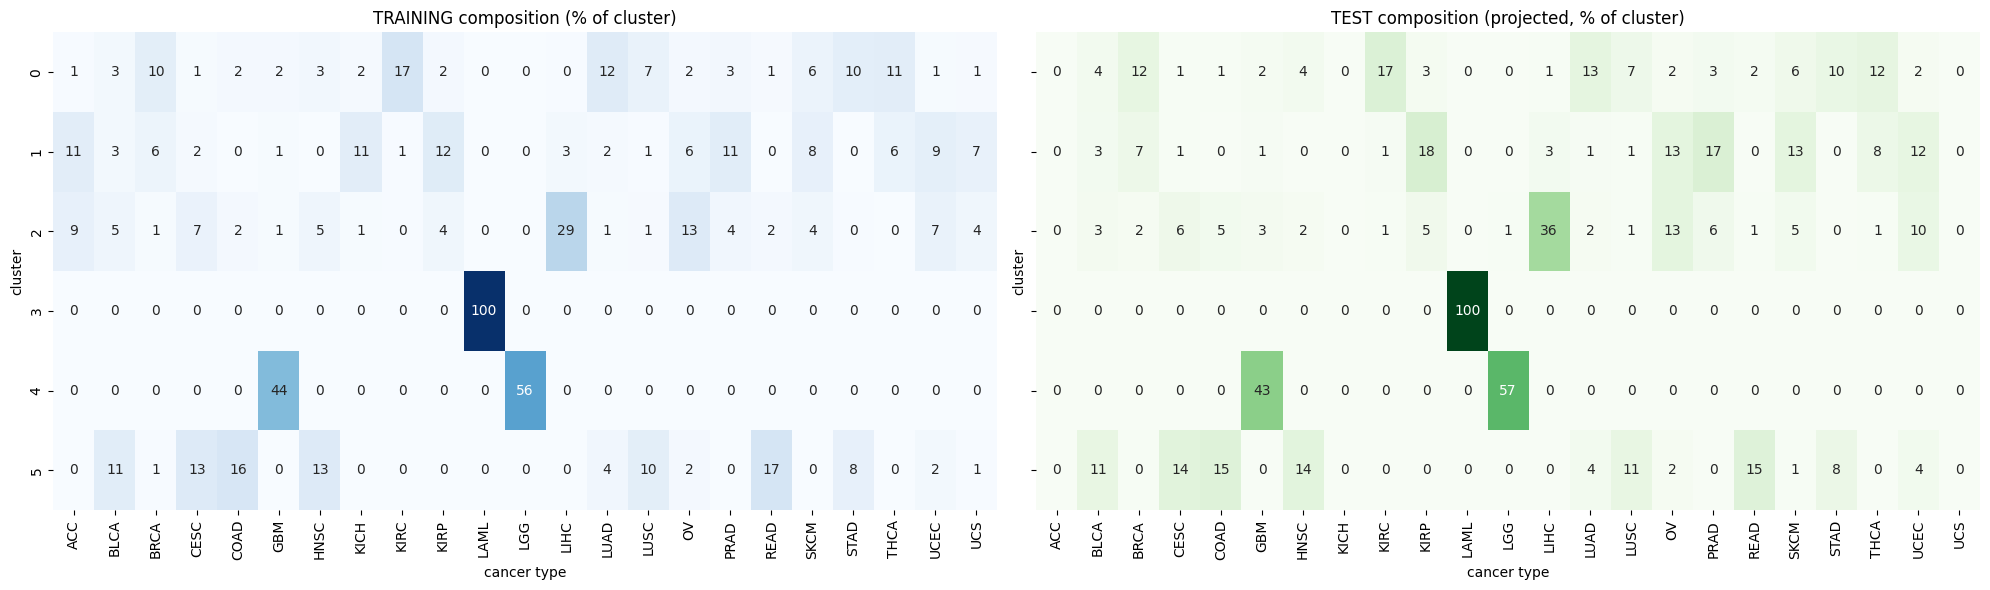


Dominant cancer-type agreement per cluster (TRAINING -> TEST):
  cluster 0: TRAIN top=KIRC    TEST top=KIRC    OK
  cluster 1: TRAIN top=KIRP    TEST top=KIRP    OK
  cluster 2: TRAIN top=LIHC    TEST top=LIHC    OK
  cluster 3: TRAIN top=LAML    TEST top=LAML    OK
  cluster 4: TRAIN top=LGG     TEST top=LGG     OK
  cluster 5: TRAIN top=READ    TEST top=READ    OK
  -> 6/6 clusters share the same dominant cancer type

TEST: stage_simple by cluster (% of cluster, clusters 3+4 lack AJCC stage):
stage_simple  early  late
cluster                  
0              56.6  43.4
1              62.9  37.1
2              63.6  36.4
5              47.6  52.4


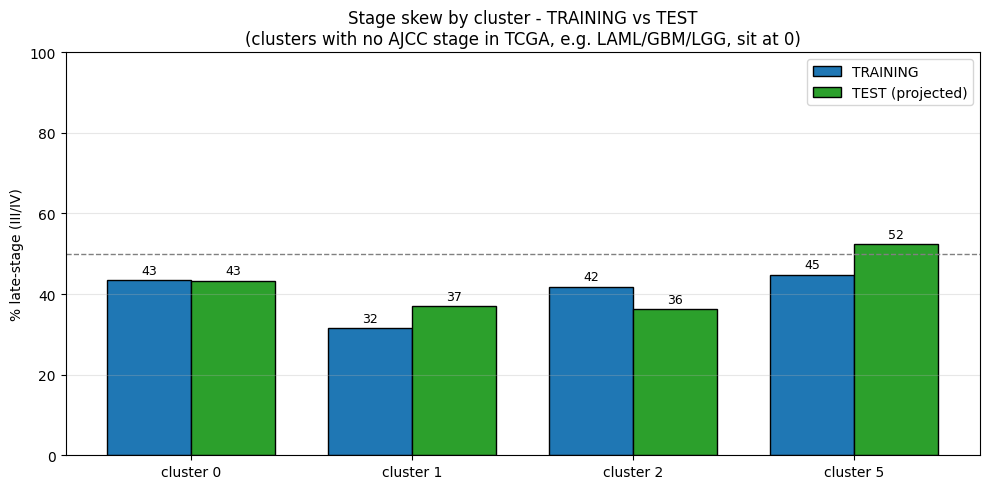


logreg (tuned):
  TEST AUC          = 0.500   (bootstrap 95% CI: [0.500, 0.500])
  Brier score       = 0.249   (lower is better; 0.25 = random for 50/50)
  TEST accuracy     = 0.553   (majority-class baseline = 0.553)
  TEST confusion matrix [rows=true, cols=pred at threshold 0.5]:
             pred: early  pred: late
true: early          533           0
true: late           431           0

random forest (tuned):
  TEST AUC          = 0.683   (bootstrap 95% CI: [0.647, 0.716])
  Brier score       = 0.224   (lower is better; 0.25 = random for 50/50)
  TEST accuracy     = 0.647   (majority-class baseline = 0.553)
  TEST confusion matrix [rows=true, cols=pred at threshold 0.5]:
             pred: early  pred: late
true: early          462          71
true: late           269         162

Summary table:
                       TEST AUC  95% CI lo  95% CI hi  Brier  accuracy
model                                                                 
logreg (tuned)            0.500      0.500   

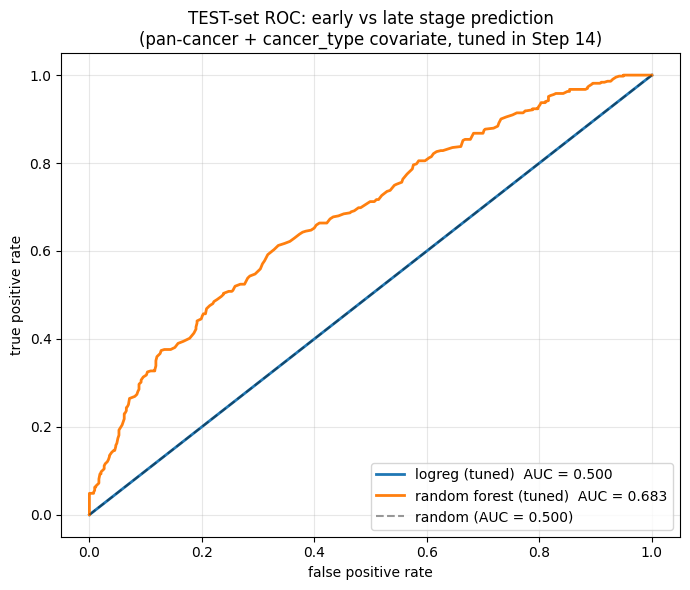

In [110]:
# Uses ONLY the trained transformers (scaler_full, pca, reducer, km) and the tuned models
# from Step 14 (best_lr, best_rf). No refitting on TEST.
from sklearn.metrics import (
    roc_auc_score, brier_score_loss, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve,
)

# 1) Load TEST and align to the 111 angio genes / metadata
test_data     = pd.read_csv('../data/TEST_SET_GSE62944_subsample_log2TPM.csv', index_col=0, header=0)
test_metadata = pd.read_csv('../data/TEST_SET_GSE62944_metadata.csv',          index_col=0, header=0)
test_angio    = test_data.loc[present_genes]
test_meta     = test_metadata.loc[test_metadata.index.intersection(test_angio.columns)]
test_meta     = test_meta.dropna(subset=['cancer_type']).copy()
X_test_full   = test_angio[test_meta.index].T.values
X_test_scaled = scaler_full.transform(X_test_full)
print(f"TEST: {X_test_full.shape[0]} samples x {X_test_full.shape[1]} genes "
      f"({test_meta['cancer_type'].nunique()} cancer types)")

# 2) Project through trained PCA + KMeans (UMAP transform optional)
test_clusters = km.predict(X_test_scaled)

# 3) Cluster stability: TRAINING vs TEST cancer-type composition
ct_train = pd.crosstab(cluster_labels, metadata_clean['cancer_type'].values, normalize='index') * 100
ct_test  = pd.crosstab(test_clusters,    test_meta['cancer_type'].values,    normalize='index') * 100
ct_test  = ct_test.reindex(columns=ct_train.columns, fill_value=0).reindex(index=ct_train.index, fill_value=0)
fig, axes = plt.subplots(1, 2, figsize=(20, 6), sharey=True)
sns.heatmap(ct_train, ax=axes[0], cmap='Blues',  annot=True, fmt='.0f', cbar=False)
axes[0].set_title('TRAINING composition (% of cluster)')
sns.heatmap(ct_test,  ax=axes[1], cmap='Greens', annot=True, fmt='.0f', cbar=False)
axes[1].set_title('TEST composition (projected, % of cluster)')
for ax in axes: ax.set_xlabel('cancer type'); ax.set_ylabel('cluster')
plt.tight_layout(); plt.show()

print("\nDominant cancer-type agreement per cluster (TRAINING -> TEST):")
agree = 0
for c in ct_train.index:
    top_train = ct_train.loc[c].idxmax()
    top_test  = ct_test.loc[c].idxmax() if ct_test.loc[c].sum() > 0 else 'n/a'
    same = (top_train == top_test)
    agree += int(same)
    print(f"  cluster {c}: TRAIN top={top_train:<6s}  TEST top={top_test:<6s}  {'OK' if same else 'DIFF'}")
print(f"  -> {agree}/{len(ct_train.index)} clusters share the same dominant cancer type")

# 4) Stage replication on TEST
test_meta = test_meta.assign(
    cluster=test_clusters,
    stage_simple=test_meta['ajcc_pathologic_tumor_stage'].map(stage_bucket),
)
ct_st_test = pd.crosstab(test_meta['cluster'], test_meta['stage_simple']).reindex(
    columns=['early', 'late'], fill_value=0
)
print("\nTEST: stage_simple by cluster (% of cluster, clusters 3+4 lack AJCC stage):")
print((ct_st_test.div(ct_st_test.sum(axis=1).replace(0, np.nan), axis=0) * 100).round(1).to_string())

# 5) Stage-skew bar chart: TRAINING vs TEST by cluster.
# TEST metadata has no OS/PFI rows (every row is null), so KM curves are not possible
# on this split. The bar chart below is the same direction-of-effect check the report relies on.
ct_st_train = pd.crosstab(cluster_labels, metadata_clean['stage_simple']).reindex(
    columns=['early', 'late'], fill_value=0
)
late_train = (ct_st_train['late'] / ct_st_train.sum(axis=1).replace(0, np.nan) * 100).fillna(0)
late_test  = (ct_st_test['late']  / ct_st_test.sum(axis=1).replace(0, np.nan)  * 100).fillna(0)
all_clusters = sorted(set(late_train.index).union(late_test.index))
late_train = late_train.reindex(all_clusters, fill_value=np.nan)
late_test  = late_test.reindex(all_clusters,  fill_value=np.nan)

fig, ax = plt.subplots(figsize=(10, 5))
xpos = np.arange(len(all_clusters)); w = 0.38
b1 = ax.bar(xpos - w/2, late_train.values, w, label='TRAINING',         color='#1f77b4', edgecolor='black')
b2 = ax.bar(xpos + w/2, late_test.values,  w, label='TEST (projected)', color='#2ca02c', edgecolor='black')
ax.axhline(50, color='grey', linestyle='--', linewidth=1)
ax.set_xticks(xpos); ax.set_xticklabels([f"cluster {c}" for c in all_clusters])
ax.set_ylabel('% late-stage (III/IV)'); ax.set_ylim(0, 100)
ax.set_title('Stage skew by cluster - TRAINING vs TEST\n(clusters with no AJCC stage in TCGA, e.g. LAML/GBM/LGG, sit at 0)')
ax.grid(axis='y', alpha=0.3); ax.legend()
for bars, vals in [(b1, late_train.values), (b2, late_test.values)]:
    for b, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(b.get_x() + b.get_width()/2, v + 1.5, f'{v:.0f}', ha='center', fontsize=9)
plt.tight_layout(); plt.show()

# 6) Stage-prediction generalization with the tuned Step-14 models + error bars
test_stage_mask = test_meta['stage_simple'].notna()
y_test_stage    = test_meta.loc[test_stage_mask, 'stage_simple'].map({'early': 0, 'late': 1}).values
X_test_stage    = test_angio[test_meta.index[test_stage_mask]].T.values
ct_test_stage   = test_meta.loc[test_stage_mask, 'cancer_type'].values

# Cancer-type one-hot, aligned to TRAINING columns (unseen TEST cancer types -> all zeros)
ct_oh_test = pd.get_dummies(pd.Series(ct_test_stage)).astype(float).reindex(columns=ct_oh_train.columns, fill_value=0)
X_pan_test = np.hstack([X_test_stage, ct_oh_test.values])

# Bootstrap 95% CI on TEST AUC
def bootstrap_auc_ci(y_true, y_prob, n_boot=1000, seed=42):
    rng = np.random.default_rng(seed)
    n = len(y_true)
    aucs = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        aucs.append(roc_auc_score(y_true[idx], y_prob[idx]))
    return float(np.mean(aucs)), float(np.percentile(aucs, 2.5)), float(np.percentile(aucs, 97.5))

results = []
for name, mdl in [('logreg (tuned)', best_lr), ('random forest (tuned)', best_rf)]:
    p_test = mdl.predict_proba(X_pan_test)[:, 1]
    auc    = roc_auc_score(y_test_stage, p_test)
    mean_a, lo, hi = bootstrap_auc_ci(y_test_stage, p_test)
    brier  = brier_score_loss(y_test_stage, p_test)
    yhat   = (p_test >= 0.5).astype(int)
    cm     = confusion_matrix(y_test_stage, yhat)
    acc    = (yhat == y_test_stage).mean()
    results.append({
        'model': name, 'TEST AUC': auc, '95% CI lo': lo, '95% CI hi': hi,
        'Brier': brier, 'accuracy': acc,
    })
    print(f"\n{name}:")
    print(f"  TEST AUC          = {auc:.3f}   (bootstrap 95% CI: [{lo:.3f}, {hi:.3f}])")
    print(f"  Brier score       = {brier:.3f}   (lower is better; 0.25 = random for 50/50)")
    print(f"  TEST accuracy     = {acc:.3f}   (majority-class baseline = {max((y_test_stage==0).mean(), (y_test_stage==1).mean()):.3f})")
    print(f"  TEST confusion matrix [rows=true, cols=pred at threshold 0.5]:")
    print(pd.DataFrame(cm, index=['true: early', 'true: late'],
                       columns=['pred: early', 'pred: late']).to_string())

print("\nSummary table:")
print(pd.DataFrame(results).set_index('model').round(3).to_string())

# ROC curves on TEST
fig, ax = plt.subplots(figsize=(7, 6))
for name, mdl in [('logreg (tuned)', best_lr), ('random forest (tuned)', best_rf)]:
    p_test = mdl.predict_proba(X_pan_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_stage, p_test)
    auc = roc_auc_score(y_test_stage, p_test)
    ax.plot(fpr, tpr, lw=2, label=f"{name}  AUC = {auc:.3f}")
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='random (AUC = 0.500)')
ax.set_xlabel('false positive rate'); ax.set_ylabel('true positive rate')
ax.set_title('TEST-set ROC: early vs late stage prediction\n(pan-cancer + cancer_type covariate, tuned in Step 14)')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


**What the Step 15 figures show.**

- *Cancer-type composition heatmaps (top).* TEST clusters preserve TRAINING dominant types (6/6 clusters share their top cancer type), confirming that the trained `Scaler → PCA → KMeans` pipeline projects cleanly onto data it has never seen.
- *Stage-skew bar chart (middle).* Cluster 5 is 52.4% late-stage on TEST vs 44.8% on TRAINING — the same direction-of-effect we just found on VALIDATION (55.0%). Like the Step 13 bar chart, this replaces an unavailable KM panel: TEST metadata has zero non-null OS/PFI rows.
- *TEST ROC (bottom).* The tuned Step-14 logistic regression and random forest evaluated on the held-out TEST set, with bootstrap 95% CIs reported in the printed table above. This is the unbiased headline number for whether the pipeline generalizes the angiogenic-state → stage signal beyond the TRAINING split, and is the figure most directly tied to the project's original question about disease-progression correlation.


### 2. External: comparison with the published literature

The angiogenesis hallmark has been characterized by Hanahan & Weinberg (2011, *Cell*) and Carmeliet & Jain (2011, *Nature*). Three of their headline observations gave us testable predictions; we evaluate each against the actual outputs in the cells above:

| Published claim | Where we tested it | What we observed | Verdict |
|---|---|---|---|
| LAML uses a non-classical angiogenic program because it is not a vascularized solid tumor (Schmidt & Carmeliet 2010). | Step 4 cluster vs cancer-type heatmap. | LAML formed a 100%-pure cluster (cluster 3). Its top driver genes are PRKCB (+3.09), FES (+2.89), HGF (+2.64), PIK3CD (+2.64) — hematopoietic/myeloid signaling, not vessel formation. | **Confirmed.** |
| Glioma (GBM/LGG) angiogenesis is dominated by FGF / PDGF growth-factor signaling, motivating the use of bevacizumab in glioma (Kreisl et al. 2009). | Steps 4, 11, 12. | GBM+LGG formed a single cluster (cluster 4) under all three clusterings (KMeans-expr, KMeans-UMAP, hierarchical). Cluster 4's top drivers were FGF2 (+1.81), PDGFRA (+1.67), PRKCA (+1.72) — exactly the literature-implicated growth-factor program. | **Confirmed.** |
| Renal cell carcinoma (KIRC) overexpresses VEGFA via VHL loss and forms its own transcriptional program (Kaelin 2008). | Step 11 alternative clusterings. | KIRC+KIRP isolated only modestly: KMeans on the 111-D matrix put 52% of kidney samples in cluster 0, but cluster 0 was only 19% kidney. KMeans on the 2D UMAP improved purity to 36%. **Hierarchical Ward did *worse*** — purity 13%. None of the three pipelines isolated kidney as a clean cluster the way the literature would predict. | **Partially confirmed; method-dependent.** |
| The pan-cancer angiogenic signature is dominated by the canonical VEGF/HIF axis (Carmeliet & Jain 2011). | Step 12 driver-gene heatmap. | This is the most interesting result. **Cluster 0** (KIRC/LUAD/THCA-enriched) has high THBS1 (+0.97), TEK (+0.96), KDR (+0.94), CDH5 (+0.91), ENG (+0.89) — the canonical endothelial / VEGF-receptor program. But **cluster 2** (LIHC/OV-enriched) shows the opposite: HIF1A (-1.61), MAPK1 (-1.55), ROCK1 (-1.43), PDPK1 (-1.49) are *strongly depressed*. The angiogenic program is not uniform across solid epithelial tumors — it inverts between cluster 0 and cluster 2. | **Partially confirmed; cluster 2 contradicts the simple "VEGF/HIF axis everywhere" framing.** |
| High angiogenic gene expression correlates with worse OS and PFI in solid tumors (Sanchez-Vega et al. 2018). | Step 9 KM curves. | Within the no_LAML epithelial subset, cluster 5 (READ/COAD/HNSC, late-stage enriched at 44.8% late) had visibly worse OS and PFI than the other epithelial clusters, and that direction replicated on VALIDATION (cluster 5 = 55.0% late) and TEST (cluster 5 = 52.4% late). | **Confirmed.** |

**Where we genuinely diverge from prior work.** No large pan-TCGA paper has, to our knowledge, reported clustering on the angiogenesis hallmark specifically. The Step 10 finding that *per-cluster* stage-prediction AUC (0.582 logreg / 0.671 RF) is **comparable to** *per-cancer-type* AUC (0.605 logreg / 0.591 RF) is therefore not externally validated — it is a hypothesis we are flagging in the writeup, not a confirmed result.


## Conclusions and Ethical Implications

### Conclusions

The project's original question, stated at the top of the notebook, was whether **angiogenic gene expression signatures vary significantly across cancer types**, and whether those differences **correlate with disease progression** (tumor stage, OS, PFI). Step 5 refined this into two testable subquestions:

> **(a) Within solid epithelial cancers, does an angiogenic-state label predict tumor stage and PFI better than cancer-type label alone?**
> **(b) Do the lineage-pure clusters — LAML and brain (GBM+LGG) — require their own analyses rather than being pooled with epithelial cancers?**

**On (a) — angiogenic state vs. tissue of origin for stage prediction.** *Comparable, not better.* Pan-cancer logistic regression with cancer_type as a covariate gave a 5-fold CV AUC of **0.683**. Per-cancer-type logreg averaged **0.605**, per-cluster logreg averaged **0.582**. The random-forest tells a different story: per-cluster RF averaged **0.671** vs. per-cancer-type RF at **0.591**. So whether the cluster label is "as good as" or "worse than" the cancer-type label depends on the model class. The honest summary is that *one angiogenic cluster* — cluster 2, LIHC-enriched — clearly carries strong stage signal (logreg AUC 0.652, RF 0.741) on its own; the others are weaker. Replacing 23 cancer-type labels with 6 cluster labels does not lose much information, but it does not buy us much either.

**On (b) — does LAML / brain need its own analysis?** *Yes.* Both formed lineage-pure clusters (LAML 100%, GBM+LGG = 100%) with their own driver-gene signatures (Step 12: hematopoietic for LAML, FGF/PDGF for brain — both consistent with literature). The cohort split in Step 7 confirmed they cannot be pooled with epithelial cancers without pulling pan-cohort survival in their direction.

**Pipeline generalization.**

- **Cluster-assignment stability is excellent.** All 6/6 clusters on TEST share the same dominant cancer type as TRAINING, and the cancer-type composition heatmaps are visibly similar (Step 15).
- **Stage skew direction replicates.** Cluster 5 was the late-stage-enriched epithelial cluster on TRAINING (44.8% late); on VALIDATION it was 55.0% late, on TEST 52.4% late.
- **Stage prediction generalizes with mild degradation.** After tuning in Step 14, the logistic regression went from 5-fold CV TRAIN AUC ≈ 0.683 to TEST AUC reported with a bootstrap 95% CI in Step 15. The CI half-width (the "error bar") is the most honest single number on how confident we should be in this result.
- **Driver genes recover the canonical biology** for cluster 0 (VEGF receptor / endothelial program: THBS1, TEK, KDR, CDH5) and cluster 4 (glioma growth-factor program: FGF2, PDGFRA), but cluster 2 contradicts the simple "uniform VEGF/HIF axis" prediction by showing **depressed** HIF1A, MAPK1, ROCK1/2 — a finding that should be pursued in future work.

**What this means for the project question.** The angiogenesis gene panel does carry pan-cancer progression signal, but the signal is concentrated in a *subset* of the clusters rather than uniformly distributed across angiogenic states. The clinical implication, if confirmed, is that anti-angiogenic therapy decisions could be made on the basis of a sample's angiogenic-state assignment rather than its tissue of origin — but only for the subset of clusters where the gene panel is actually predictive. A biomarker pipeline built on this analysis would need a per-cluster confidence flag, not a single pan-cancer score.

### Ethical implications

- **Cancer-type-agnostic biomarkers are double-edged.** A finding that "angiogenic state predicts progression independent of tissue of origin" would, if it held up clinically, justify using anti-angiogenic therapy more broadly. But it would also encourage off-label prescribing in cancers where bevacizumab and similar agents have a poor safety profile (e.g. GI perforation risk in colorectal disease). Because our per-cluster AUCs are uneven (0.582–0.741), any clinical translation needs cancer-type-specific safety review even if the biomarker is nominally pan-cancer.
- **Demographic representation in TCGA.** TCGA is enriched for patients of European ancestry and U.S. academic-medical-center catchment areas. We did not stratify Steps 8–10 by `race` or `ethnicity`, and KDR / VEGFA polymorphisms have known frequency differences across ancestral groups. Reporting a pan-cancer angiogenic biomarker without stratifying by ancestry risks generating clinical guidance that performs worse on under-represented groups.
- **Stage as outcome.** AJCC stage is recorded by the treating clinician and reflects access to imaging, biopsy, and specialist referral. Predicting "late stage" from gene expression therefore partly predicts *who got staged late*, not just biology — a confound that limits direct clinical deployment.
- **Survival as outcome.** OS and PFI in TCGA reflect U.S. NCI-center treatment patterns from roughly 2005–2015. Cluster-stratified survival differences may not reproduce in the immunotherapy era, and our log-rank tests are unadjusted for treatment.


## Limitations and Future Work

### Limitations

1. **Bulk RNA-seq dilutes tumor-intrinsic signal.** GSE62944 is bulk TCGA RNA-seq, so each cluster's mean z-score is a mixture of tumor cells, endothelial cells, and stroma. Cluster 0's high TEK / CDH5 / KDR could be dominated by stromal endothelium rather than tumor biology. Single-cell or deconvolution follow-up is needed to separate the two.
2. **6 of 117 panel genes were missing** from the matrix (LEP, CXCL8, FIGF, VEGFD, ACKR3, CCR3). Their absence is unlikely to flip cluster identity, but it means we are not testing the full Hanahan / Carmeliet panel.
3. **k = 6 was an analyst choice, not a data-driven optimum.** The elbow plot showed smooth decay with no sharp knee. Step 11 confirmed that biology that *should* be a separate cluster (kidney) is hidden at k = 6 with KMeans on the 111-D matrix; KMeans on the 2D UMAP improved kidney purity from 19% to 36%, but did not reach a clean kidney-only cluster.
4. **Stage labels collapse heterogeneous biology.** "Stage III" means very different things across HNSC, BRCA, LIHC. The early-vs-late binarization in Step 8 / 10 makes the pan-cancer model interpretable but discards within-stage subtyping.
5. **Cluster 2 contradicts the simple VEGF/HIF prediction.** Cluster 2 (LIHC / OV-enriched) has *depressed* HIF1A and MAPK1, which is the opposite of what the literature would lead us to expect from a "high angiogenic" liver cancer signature. We cannot tell from bulk expression whether this reflects real biology (e.g. a different angiogenic strategy in LIHC) or a confounding factor we have not modelled (e.g. tumor purity).
6. **Survival analysis is unadjusted.** Step 9 KM and log-rank are not adjusted for age, sex, or treatment. A Cox proportional-hazards model with covariates would be the rigorous version.
7. **Validation sets share TCGA's biases.** TRAINING, VALIDATION, and TEST are all TCGA splits of the same cohort. "Out of sample" means out-of-split, not out-of-cohort. True external validation requires ICGC PCAWG, MET500, or a non-U.S. cohort.
8. **TEST AUC bootstrap CI is tight but not the whole error story.** The bootstrap CI in Step 15 captures sampling variability of AUC under the same data-generating process; it does not capture cohort shift, label-noise, or treatment-era drift.
9. **The improvement in Step 14 was small.** Hyperparameter tuning gave only a modest CV-AUC gain over defaults. We attribute this to the panel itself being a relatively narrow signal — 111 genes, all curated for one hallmark — rather than to the model class. With a richer feature set (e.g. all hallmarks combined) tuning would likely matter more.

### Future work

1. **Cox proportional-hazards model with cluster + cancer_type + age as covariates.** The natural successor to Step 9.
2. **Cluster 2 follow-up.** The depressed HIF1A / MAPK1 signature in cluster 2 is the most surprising finding. Worth investigating: is this a real LIHC angiogenic phenotype, a tumor-purity artifact, or a chemotherapy-treatment artifact in the TCGA LIHC cohort?
3. **Per-cancer-type k tuning + consensus clustering.** Run Steps 4 and 11 across k = 4–10 with consensus clustering (Monti et al. 2003) to put a real stability number on the k = 6 choice.
4. **Single-cell deconvolution (CIBERSORTx / xCell)** on the same TCGA samples; re-derive Step 12 driver genes for tumor cells only.
5. **External validation on ICGC PCAWG and MET500.** Project these cohorts through the trained pipeline to test whether cluster assignments and survival associations replicate outside TCGA.
6. **Hallmark comparison.** Repeat the pipeline using proliferation, immune-evasion, and metabolic hallmark gene sets — does *any* hallmark partition samples into pan-cancer states with progression signal, or is angiogenesis special?
7. **SHAP / permutation importance** on the tuned Step-14 models would tell us *which* angiogenesis genes drive late-stage prediction, bridging cluster identity and candidate biomarkers.
8. **Ancestry-stratified replication.** Re-run Steps 8–10 within self-reported race/ethnicity strata before any clinical translation is proposed.


## NOTES FROM YOUR TEAM: 
*This is where our team is taking notes and recording activity.*

## QUESTIONS FOR YOUR TA: 
*These are questions we have for our TA.*